# 1. Data Ingestion

## 1.1 Fetching Eval Datasets

### 1.1a FinanceQA Dataset(INDIA)

In [19]:
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset

import os

# Load .env
load_dotenv()

# Read token
hf_token = os.getenv("HUGGING_FACE_TOKEN")

# Authenticate
login(token=hf_token)

In [20]:
from datasets import load_dataset
import pandas as pd
import os

os.makedirs("data/India/eval", exist_ok=True)

dataset = load_dataset("sweatSmile/FinanceQA")

print(dataset)

# Convert train split to pandas
df = dataset["train"].to_pandas()

# Save locally
df.to_parquet("data/India/eval/financeqa.parquet")

print("Saved FinanceQA dataset")

DatasetDict({
    train: Dataset({
        features: ['COMPANY_ID', 'QUERY', 'ANSWER', 'CONTEXT', '__index_level_0__'],
        num_rows: 3705
    })
    test: Dataset({
        features: ['COMPANY_ID', 'QUERY', 'ANSWER', 'CONTEXT', '__index_level_0__'],
        num_rows: 927
    })
})
Saved FinanceQA dataset


In [21]:
df

,COMPANY_ID,QUERY,ANSWER,CONTEXT,__index_level_0__
0,ARCOTECH_2023_converted.txt_0,What is the equity share capital of the company?,The equity share capital of the company is 21.,Symbol: ARCOTECH Company Name: Arcotech Ltd. E...,881
1,MAHSCOOTER_2023_converted.txt_1,What are the total shareholders' funds of the ...,The total shareholders' funds of the company a...,Symbol: MAHSCOOTER Company Name: Maharashtra S...,1501
2,AGI_2023_converted.txt_1,What is the total reserves and surplus of the ...,Total reserves and surplus of the company is 1...,Symbol: AGI Company Name: AGI Greenpac Ltd. EQ...,1204
3,JBMA_2023_converted.txt_2,What are the deferred tax liabilities of the c...,The deferred tax liabilities of the company ar...,Symbol: JBMA Company Name: JBM Auto Ltd. EQUIT...,2222
4,TTKHLTCARE_2023_converted.txt_3,What is the total value of assets of the company?,"The total value of assets of the company is 1,...",Liabilities: 210.78 Total Capital And Liabilit...,4017
...,...,...,...,...,...
3700,MTNL_2023_converted.txt_3,What is the expenditure in foreign currency of...,The expenditure in foreign currency of the com...,"11,634.64 OTHER ADDITIONAL INFORMATION: nan CO...",4426
3701,SHARDAMOTR_2023_converted.txt_0,What is the equity share capital of the company?,The equity share capital of the company is 5.95.,Symbol: SHARDAMOTR Company Name: Sharda Motor ...,466
3702,KRIDHANINF_2023_converted.txt_2,What is the Asset Turnover Ratio of the company?,The Asset Turnover Ratio of the company is 0.71.,12.06 Net Profit Margin (%): 8.28 Return on Ne...,3092
3703,SAIL_2023_converted.txt_4,What is the total value of assets of the company?,The total value of assets of the company is 12...,"Total Current Liabilities: 49,305.47 Total Cap...",3772


### 1.1b BhashaBench Dataset(INDIA)

In [22]:
from datasets import load_dataset
import os

os.makedirs("data/India/eval", exist_ok=True)

dataset = load_dataset("bharatgenai/BhashaBench-Finance",'English')
dataset.save_to_disk("data/India/eval/bhashabench_finance")

Saving the dataset (1/1 shards): 100%|██████████| 13451/13451 [00:00<00:00, 721249.56 examples/s]


### 1.1c FinanceBench Dataset(US)

In [23]:
from pathlib import Path

eval_dir = Path("data/us/eval")
eval_dir.mkdir(parents=True, exist_ok=True)

!git clone https://github.com/patronus-ai/financebench.git data/us/eval/financebench

Cloning into 'data/us/eval/financebench'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 428 (delta 5), reused 3 (delta 3), pack-reused 409 (from 1)
Receiving objects: 100% (428/428), 552.37 MiB | 4.14 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Updating files: 100% (390/390), done.


In [26]:
import pandas as pd

df = pd.read_json(
    "data/us/eval/financebench/data/financebench_open_source.jsonl",
    lines=True,
)

In [27]:
df

,financebench_id,company,doc_name,question_type,question_reasoning,domain_question_num,question,answer,justification,dataset_subset_label,evidence
0,financebench_id_03029,3M,3M_2018_10K,metrics-generated,Information extraction,NaN,What is the FY2018 capital expenditure amount ...,$1577.00,The metric capital expenditures was directly e...,OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...
1,financebench_id_04672,3M,3M_2018_10K,metrics-generated,Information extraction,NaN,Assume that you are a public equities analyst....,$8.70,"The metric ppne, net was directly extracted fr...",OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...
2,financebench_id_00499,3M,3M_2022_10K,domain-relevant,Logical reasoning (based on numerical reasoning),dg06,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...",CAPEX/Revenue\nFixed Assets/Total Assets\nROA=...,OPEN_SOURCE,[{'evidence_text': '3M Company and Subsidiarie...
3,financebench_id_01226,3M,3M_2022_10K,domain-relevant,Logical reasoning (based on numerical reasonin...,dg17,What drove operating margin change as of FY202...,Operating Margin for 3M in FY2022 has decrease...,NaN,OPEN_SOURCE,"[{'evidence_text': 'SG&A, measured as a percen..."
4,financebench_id_01865,3M,3M_2022_10K,novel-generated,NaN,NaN,"If we exclude the impact of M&A, which segment...",The consumer segment shrunk by 0.9% organically.,NaN,OPEN_SOURCE,[{'evidence_text': 'Worldwide Sales Change By...
...,...,...,...,...,...,...,...,...,...,...,...
145,financebench_id_00215,Verizon,VERIZON_2022_10K,domain-relevant,Logical reasoning (based on numerical reasoning),dg06,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,capital intensity ratio = total asset / revenu...,OPEN_SOURCE,[{'evidence_text': 'Consolidated Balance Sheet...
146,financebench_id_00566,Verizon,VERIZON_2022_10K,domain-relevant,Numerical reasoning,dg22,Has Verizon increased its debt on balance shee...,No. Verizon's debt decreased by $229 million.,debt change = debt in 2022 - debt in 2021 = 15...,OPEN_SOURCE,"[{'evidence_text': 'At December 31, Maturities..."
147,financebench_id_06247,Walmart,WALMART_2018_10K,metrics-generated,Numerical reasoning,NaN,What is FY2018 days payable outstanding (DPO) ...,42.69,The metric in question was calculated using ot...,OPEN_SOURCE,[{'evidence_text': 'Walmart Inc. Consolidated ...
148,financebench_id_04784,Walmart,WALMART_2019_10K,metrics-generated,Numerical reasoning,NaN,Based on the information provided primarily in...,0.2%,The metric in question was calculated using ot...,OPEN_SOURCE,[{'evidence_text': 'WalmartInc. ConsolidatedSt...


## 1.2 Fetching PDFs 

In [ ]:
"""
fetch_pdfs.py

A single class for downloading annual report PDFs (India) and SEC filings (US)
via four different methods. Pick whichever suits your situation:

    - from_urls():  bulk download from a CSV of pre-collected URLs (most reliable
                    for Indian market — see urls.csv shipped alongside this file)
    - from_sec():   SEC EDGAR API for US-listed companies (best for US market)
    - from_bse():   BSE India announcements endpoint (useful only for current news)
    - from_nse():   NSE India announcements endpoint (useful only for current news)

Usage as a library
------------------
    from fetch_pdfs import FetchPDFs

    # India: bulk download from CSV
    fetcher = FetchPDFs(output_dir="data/india")
    records = fetcher.from_urls("urls.csv")

    # US: SEC EDGAR (requires your name + email for SEC's User-Agent policy)
    fetcher = FetchPDFs(
        output_dir="data/us",
        sec_user_agent_name="Your Name",
        sec_user_agent_email="you@example.com",
    )
    records = fetcher.from_sec(["AAPL", "MSFT", "NVDA"], num_filings=3)

Usage as CLI
------------
    python fetch_pdfs.py urls --csv urls.csv --out data/india
    python fetch_pdfs.py sec  --tickers AAPL,MSFT,NVDA --num-filings 3 \\
                              --out data/us --name "Your Name" --email "you@example.com"
    python fetch_pdfs.py bse  --tickers TCS,INFY --out data/india
    python fetch_pdfs.py nse  --tickers TCS,INFY --out data/india
"""

from __future__ import annotations

import argparse
import json
import time
from pathlib import Path
from typing import Iterable, Optional, Union

import pandas as pd
import requests
from tqdm import tqdm


class FetchPDFs:
    """Download financial filings via URL list, SEC EDGAR, BSE, or NSE."""

    # Browser-like headers; required because most IR sites and BSE/NSE attachment
    # CDNs block requests without a recognized User-Agent.
    DEFAULT_HEADERS = {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
        "Accept": "application/pdf,application/octet-stream,*/*",
        "Accept-Language": "en-US,en;q=0.9",
    }

    # Keywords used to identify "this announcement is an annual report" in
    # subject lines returned by NSE/BSE corporate-filings APIs. BSE files
    # annual reports under several wordings — we cast a fairly wide net here
    # and rely on the PDF-magic-number check in _download_pdf to reject
    # non-PDF noise.
    ANNUAL_REPORT_MARKERS = (
        "annual report",
        "annual-report",
        "ar fy",
        "ar for",
        "annualreport",
        "integrated annual report",
        "integrated report",
        "reg. 34",
        "reg 34",
        "regulation 34",
        "regulation 34(1)",
    )

    MIN_VALID_PDF_BYTES = 10_000  # below this we treat the file as junk / notice

    def __init__(
        self,
        output_dir: Union[str, Path] = "data/pdfs",
        polite_delay: float = 1.5,
        max_retries: int = 3,
        retry_backoff: float = 5.0,
        timeout: int = 60,
        sec_user_agent_name: Optional[str] = None,
        sec_user_agent_email: Optional[str] = None,
    ):
        """
        Args:
            output_dir: Where downloaded files go.
            polite_delay: Seconds between successful downloads.
            max_retries: HTTP retry count.
            retry_backoff: Backoff multiplier in seconds.
            timeout: Per-request timeout in seconds.
            sec_user_agent_name: Your name (required by SEC EDGAR for from_sec()).
                Can also be passed per-call. Not used by other methods.
            sec_user_agent_email: Your email (required by SEC EDGAR for from_sec()).
                Can also be passed per-call. Not used by other methods.
        """
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.polite_delay = polite_delay
        self.max_retries = max_retries
        self.retry_backoff = retry_backoff
        self.timeout = timeout
        self.sec_user_agent_name = sec_user_agent_name
        self.sec_user_agent_email = sec_user_agent_email
        self._session = requests.Session()
        self._session.headers.update(self.DEFAULT_HEADERS)

    # ------------------------------------------------------------------ #
    # Public API
    # ------------------------------------------------------------------ #

    def from_urls(self, csv_path: Union[str, Path]) -> list[dict]:
        """Download PDFs whose URLs are listed in a CSV.

        Required columns: company, year, pdf_url
        Optional columns: sector, nse_symbol, bse_code

        Writes manifest.json into output_dir. Returns the manifest records.
        """
        df = pd.read_csv(csv_path)
        required = {"company", "year", "pdf_url"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"CSV missing required columns: {missing}")

        df = df[df["pdf_url"].notna() & (df["pdf_url"].str.strip() != "")]
        if df.empty:
            raise ValueError(
                "No URLs to download. Fill in the pdf_url column first."
            )

        records: list[dict] = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="from_urls"):
            out_path = self.output_dir / row["company"] / f"{row['year']}.pdf"
            ok, error = self._download_pdf(row["pdf_url"], out_path)
            records.append({
                "source_method": "urls",
                "company": row["company"],
                "year": int(row["year"]),
                "sector": row.get("sector", ""),
                "nse_symbol": row.get("nse_symbol", ""),
                "bse_code": row.get("bse_code", ""),
                "source_url": row["pdf_url"],
                "local_path": str(out_path),
                "size_bytes": out_path.stat().st_size if out_path.exists() else 0,
                "status": "ok" if ok else "failed",
                "error": error,
            })

        self.write_manifest(records, "manifest.json")
        self._print_summary(records)
        return records

    def from_sec(
        self,
        tickers: Union[str, Iterable[str]],
        filing_type: str = "10-K",
        num_filings: int = 3,
        after: Optional[str] = None,
        before: Optional[str] = None,
        user_agent_name: Optional[str] = None,
        user_agent_email: Optional[str] = None,
    ) -> list[dict]:
        """Download US SEC filings via the EDGAR API.

        The SEC requires identification in every request's User-Agent header.
        Pass your real name and email — they are not registered or used for
        any account, only logged on SEC's side for compliance / abuse tracking.

        Args:
            tickers: Comma-separated string or iterable of US tickers,
                e.g. "AAPL,MSFT,NVDA" or ["AAPL", "MSFT", "NVDA"].
            filing_type: SEC form name. Common values:
                "10-K"  annual report (use this for RAG corpus)
                "10-Q"  quarterly report
                "8-K"   current events
                "DEF 14A" proxy statement
            num_filings: Number of most recent filings to download per ticker.
                Ignored if both `after` and `before` are supplied.
            after: Optional ISO date "YYYY-MM-DD" — only filings on/after this date.
            before: Optional ISO date "YYYY-MM-DD" — only filings on/before this date.
            user_agent_name: Override the class-level SEC identification name.
            user_agent_email: Override the class-level SEC identification email.

        Returns:
            List of manifest records. Each record has fields: ticker, year,
            filing_type, accession_number, source_url, local_path, status.

        Notes:
            - Files land at {output_dir}/{TICKER}/{YEAR}_{accession}.htm
              (we copy the primary 10-K HTML out of the library's nested folder
              structure so the corpus layout matches the from_urls() output).
            - The full nested download remains at
              {output_dir}/sec-edgar-filings/{TICKER}/{filing_type}/{accession}/
              in case you need other documents from the same filing.
            - The 10-K HTML is what you want to ingest. The .txt full submission
              is a concatenated dump that's much harder to parse.
        """
        try:
            from sec_edgar_downloader import Downloader
        except ImportError as e:
            raise ImportError(
                "The 'sec-edgar-downloader' package is required for from_sec(). "
                "Install it with:  pip install sec-edgar-downloader"
            ) from e

        name = user_agent_name or self.sec_user_agent_name
        email = user_agent_email or self.sec_user_agent_email
        if not name or not email:
            raise ValueError(
                "from_sec() requires SEC EDGAR identification (name + email). "
                "Pass them to FetchPDFs(...) or to from_sec(...) directly. "
                "SEC requires this in every request's User-Agent header."
            )

        tickers = self._normalize_tickers(tickers)
        records: list[dict] = []

        # The Downloader creates {output_dir}/sec-edgar-filings/{TICKER}/{form}/{accession}/
        # underneath whatever folder we hand it. We pass our class-level output_dir
        # so everything stays in one tree.
        dl = Downloader(name, email, str(self.output_dir))

        for ticker in tqdm(tickers, desc="from_sec"):
            records.extend(
                self._process_sec_ticker(
                    ticker, dl, filing_type, num_filings, after, before
                )
            )

        self.write_manifest(records, "sec_manifest.json")
        self._print_summary(records)
        return records

    def from_bse(self, tickers: Union[str, Iterable[str]]) -> list[dict]:
        """Download annual reports via BSE India announcements endpoint.

        Resolves each ticker to a scrip code, lists recent announcements,
        filters for annual reports, and downloads the attached PDFs.

        Returns the manifest records.
        """
        try:
            from bse import BSE
        except ImportError as e:
            raise ImportError(
                "The 'bse' package is required for from_bse(). "
                "Install it with: pip install bse"
            ) from e

        tickers = self._normalize_tickers(tickers)
        records: list[dict] = []

        with BSE(download_folder=str(self.output_dir)) as bse_client:
            for ticker in tqdm(tickers, desc="from_bse"):
                records.extend(self._process_bse_ticker(ticker, bse_client))

        self.write_manifest(records, "bse_manifest.json")
        self._print_summary(records, method_hint="bse")
        return records

    def from_nse(self, tickers: Union[str, Iterable[str]]) -> list[dict]:
        """Download annual reports via NSE India announcements endpoint.

        Run after market hours (after 4 PM IST) to avoid rate-limiting.
        Returns the manifest records.
        """
        try:
            from nse import NSE
        except ImportError as e:
            raise ImportError(
                "The 'nse' package is required for from_nse(). "
                "Install it with: pip install -U nse"
            ) from e

        tickers = self._normalize_tickers(tickers)
        records: list[dict] = []

        with NSE(download_folder=str(self.output_dir)) as nse_client:
            for ticker in tqdm(tickers, desc="from_nse"):
                records.extend(self._process_nse_ticker(ticker, nse_client))

        self.write_manifest(records, "nse_manifest.json")
        self._print_summary(records, method_hint="nse")
        return records

    def write_manifest(self, records: list[dict], name: str) -> Path:
        """Write a JSON manifest into output_dir."""
        manifest_path = self.output_dir / name
        with open(manifest_path, "w") as f:
            json.dump(records, f, indent=2)
        return manifest_path

    # ------------------------------------------------------------------ #
    # Diagnostic helpers — run these when from_bse() / from_nse() return
    # empty results, to see what the underlying API actually gave back.
    # ------------------------------------------------------------------ #

    def inspect_bse(self, ticker: str, max_rows: int = 20) -> list[dict]:
        """Fetch BSE announcements for a ticker and print a summary.

        Useful when from_bse() returns no records — shows you the actual
        headlines and field names so you can see whether annual reports
        are simply absent from BSE's recent-announcements window, or
        whether the keyword filter is missing them.
        """
        from bse import BSE

        with BSE(download_folder=str(self.output_dir)) as bse_client:
            try:
                scrip_code = bse_client.getScripCode(ticker)
            except Exception as e:
                print(f"Could not resolve scrip code for {ticker}: {e}")
                return []
            print(f"[{ticker}] scrip code = {scrip_code}")

            try:
                anns = bse_client.announcements(scripcode=str(scrip_code))
            except Exception as e:
                print(f"Announcement fetch failed: {e}")
                return []

        rows = anns.get("Table", []) if isinstance(anns, dict) else anns
        print(f"[{ticker}] {len(rows)} total announcements returned")

        if rows:
            print(f"[{ticker}] available fields: {sorted(rows[0].keys())}")
            print(f"\nFirst {min(max_rows, len(rows))} headlines:")
            for r in rows[:max_rows]:
                headline = (r.get("HEADLINE") or "")[:80]
                category = r.get("SUBCATNAME") or r.get("NEWSSUB") or ""
                date = (r.get("NEWS_DT") or r.get("DT_TM") or "")[:10]
                marker = " <- looks like AR" if self._is_annual_report(
                    r.get("HEADLINE"), r.get("SUBCATNAME")
                ) else ""
                print(f"  {date}  [{category[:20]:20}]  {headline}{marker}")

        return rows

    def inspect_nse(self, ticker: str, max_rows: int = 20) -> list[dict]:
        """Fetch NSE announcements for a ticker and print a summary."""
        from nse import NSE

        with NSE(download_folder=str(self.output_dir)) as nse_client:
            try:
                if hasattr(nse_client, "announcements"):
                    anns = nse_client.announcements(symbol=ticker)
                else:
                    anns = nse_client.corporateAnnouncements(symbol=ticker)
            except Exception as e:
                print(f"Announcement fetch failed: {e}")
                return []

        rows = anns if isinstance(anns, list) else anns.get("data", [])
        print(f"[{ticker}] {len(rows)} total announcements returned")
        if rows:
            print(f"[{ticker}] available fields: {sorted(rows[0].keys())}")
            print(f"\nFirst {min(max_rows, len(rows))} subjects:")
            for r in rows[:max_rows]:
                subject = (r.get("desc") or r.get("subject") or "")[:80]
                date = (r.get("an_dt") or r.get("dt") or "")[:10]
                marker = " <- looks like AR" if self._is_annual_report(
                    r.get("desc"), r.get("subject")
                ) else ""
                print(f"  {date}  {subject}{marker}")
        return rows

    def close(self):
        """Close the underlying HTTP session."""
        self._session.close()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, tb):
        self.close()

    # ------------------------------------------------------------------ #
    # Internal helpers — used by all three public methods
    # ------------------------------------------------------------------ #

    def _download_pdf(
        self,
        url: str,
        out_path: Path,
        session: Optional[requests.Session] = None,
    ) -> tuple[bool, Optional[str]]:
        """Download a single PDF with retries.

        Returns (success, error_message). Success means the file already
        existed or was newly downloaded and looks like a PDF.
        """
        if out_path.exists() and out_path.stat().st_size > self.MIN_VALID_PDF_BYTES:
            return True, None

        out_path.parent.mkdir(parents=True, exist_ok=True)
        session = session or self._session

        for attempt in range(1, self.max_retries + 1):
            try:
                with session.get(
                    url,
                    timeout=self.timeout,
                    stream=True,
                    allow_redirects=True,
                ) as resp:
                    resp.raise_for_status()
                    content_type = resp.headers.get("Content-Type", "").lower()

                    first_chunk = next(resp.iter_content(chunk_size=8192), b"")
                    if not (
                        "pdf" in content_type
                        or first_chunk.startswith(b"%PDF")
                    ):
                        return False, f"not a PDF (content-type={content_type})"

                    with open(out_path, "wb") as f:
                        f.write(first_chunk)
                        for chunk in resp.iter_content(chunk_size=64 * 1024):
                            if chunk:
                                f.write(chunk)

                time.sleep(self.polite_delay)
                return True, None

            except (requests.RequestException, OSError) as e:
                if attempt == self.max_retries:
                    return False, f"failed after {self.max_retries} attempts: {e}"
                time.sleep(self.retry_backoff * attempt)

        return False, "unknown error"

    @classmethod
    def _is_annual_report(cls, *fields: str) -> bool:
        """Check if any of the supplied subject/description fields looks
        like an annual report announcement."""
        haystack = " ".join((f or "").lower() for f in fields)
        return any(marker in haystack for marker in cls.ANNUAL_REPORT_MARKERS)

    @staticmethod
    def _normalize_tickers(tickers: Union[str, Iterable[str]]) -> list[str]:
        if isinstance(tickers, str):
            tickers = tickers.split(",")
        return [t.strip().upper() for t in tickers if t and t.strip()]

    @staticmethod
    def _print_summary(records: list[dict], method_hint: str = "") -> None:
        if not records:
            msg = "\nNo records returned."
            if method_hint:
                msg += (
                    f" Run `fetcher.inspect_{method_hint}('TICKER')` to see "
                    f"what the API actually returned and whether annual "
                    f"reports are in its recent window."
                )
            print(msg)
            return
        ok = sum(1 for r in records if r["status"] == "ok")
        failed = [r for r in records if r["status"] != "ok"]
        print(f"\nDownloaded: {ok}/{len(records)}")
        if failed:
            print("Failures:")
            for r in failed[:10]:
                label = r.get("company") or r.get("ticker") or "?"
                year = r.get("year", "")
                err = r.get("error", "")
                print(f"  - {label} {year}: {err}")
            if len(failed) > 10:
                print(f"  ... and {len(failed) - 10} more")

    # ------------------------------------------------------------------ #
    # BSE-specific internal logic
    # ------------------------------------------------------------------ #

    def _process_bse_ticker(self, ticker: str, bse_client) -> list[dict]:
        records: list[dict] = []
        try:
            scrip_code = bse_client.getScripCode(ticker)
        except Exception as e:
            print(f"[BSE {ticker}] could not resolve scrip code: {e}")
            return records

        try:
            announcements = bse_client.announcements(scripcode=str(scrip_code))
        except Exception as e:
            print(f"[BSE {ticker}] announcement fetch failed: {e}")
            return records

        rows = (
            announcements.get("Table", [])
            if isinstance(announcements, dict) else announcements
        )
        annual_reports = [
            r for r in rows
            if self._is_annual_report(r.get("HEADLINE"), r.get("SUBCATNAME"))
        ]
        print(f"[BSE {ticker}] found {len(annual_reports)} annual-report announcements")

        for ann in annual_reports:
            url = self._extract_bse_url(ann)
            if not url:
                continue
            date_str = ann.get("NEWS_DT") or ann.get("DT_TM") or ""
            year = date_str[:4] if date_str else "unknown"
            news_id = ann.get("NEWSID", "x")
            out_path = self.output_dir / ticker / f"{year}_{news_id}.pdf"
            ok, error = self._download_pdf(url, out_path)
            records.append({
                "source_method": "bse",
                "ticker": ticker,
                "scrip_code": scrip_code,
                "year": year,
                "headline": ann.get("HEADLINE", ""),
                "source_url": url,
                "local_path": str(out_path),
                "status": "ok" if ok else "failed",
                "error": error,
            })

        return records

    @staticmethod
    def _extract_bse_url(announcement: dict) -> Optional[str]:
        """BSE attachment URLs may appear under several keys depending on
        endpoint version. Try the known ones."""
        for key in ("ATTACHMENTNAME", "Attachment", "AttachmentURL", "URL"):
            url = announcement.get(key)
            if not url:
                continue
            if not url.startswith("http"):
                url = f"https://www.bseindia.com/xml-data/corpfiling/AttachLive/{url}"
            return url
        return None

    # ------------------------------------------------------------------ #
    # NSE-specific internal logic
    # ------------------------------------------------------------------ #

    def _process_nse_ticker(self, ticker: str, nse_client) -> list[dict]:
        records: list[dict] = []

        try:
            if hasattr(nse_client, "announcements"):
                anns = nse_client.announcements(symbol=ticker)
            elif hasattr(nse_client, "corporateAnnouncements"):
                anns = nse_client.corporateAnnouncements(symbol=ticker)
            else:
                print(f"[NSE {ticker}] library does not expose announcements")
                return records
        except Exception as e:
            print(f"[NSE {ticker}] announcement fetch failed: {e}")
            return records

        rows = anns if isinstance(anns, list) else anns.get("data", [])
        annual_reports = [
            r for r in rows
            if self._is_annual_report(r.get("desc"), r.get("subject"))
        ]
        print(f"[NSE {ticker}] found {len(annual_reports)} annual-report announcements")

        # NSE attachments require the session cookies that the nse library
        # already negotiated, so we use its internal session for downloads.
        nse_session = (
            getattr(nse_client, "_session", None)
            or getattr(nse_client, "session", None)
        )

        for ann in annual_reports:
            attachment = ann.get("attchmntFile") or ann.get("attachment")
            if not attachment:
                continue
            if not attachment.startswith("http"):
                attachment = (
                    f"https://nsearchives.nseindia.com/corporate/{attachment}"
                )
            date_str = ann.get("an_dt") or ann.get("dt", "")
            year = date_str[:4] if date_str else "unknown"
            unique = abs(hash(attachment)) % 10**8
            out_path = self.output_dir / ticker / f"{year}_{unique}.pdf"

            ok, error = self._download_pdf(attachment, out_path, session=nse_session)
            records.append({
                "source_method": "nse",
                "ticker": ticker,
                "year": year,
                "desc": ann.get("desc", ""),
                "source_url": attachment,
                "local_path": str(out_path),
                "status": "ok" if ok else "failed",
                "error": error,
            })

        return records

    # ------------------------------------------------------------------ #
    # SEC-specific internal logic
    # ------------------------------------------------------------------ #

    def _process_sec_ticker(
        self,
        ticker: str,
        dl,
        filing_type: str,
        num_filings: int,
        after: Optional[str],
        before: Optional[str],
    ) -> list[dict]:
        """Download SEC filings for one ticker and normalize the file layout.

        The sec-edgar-downloader library drops everything into a nested
        folder structure. We do the download, then walk the result and
        copy the primary 10-K HTML out to a flat layout that matches
        the rest of this class's output convention.
        """
        records: list[dict] = []

        try:
            # If date filters are given, use them; else use limit.
            kwargs = {"download_details": True}
            if after or before:
                if after:
                    kwargs["after"] = after
                if before:
                    kwargs["before"] = before
            else:
                kwargs["limit"] = num_filings
            dl.get(filing_type, ticker, **kwargs)
        except Exception as e:
            print(f"[SEC {ticker}] download failed: {e}")
            return records

        # Library writes to {output_dir}/sec-edgar-filings/{TICKER}/{FORM}/{accession}/
        sec_root = (
            self.output_dir
            / "sec-edgar-filings"
            / ticker
            / filing_type
        )
        if not sec_root.exists():
            print(f"[SEC {ticker}] no filings landed under {sec_root}")
            return records

        for filing_dir in sorted(sec_root.iterdir()):
            if not filing_dir.is_dir():
                continue

            primary_doc = self._find_primary_sec_document(filing_dir)
            if primary_doc is None:
                print(f"[SEC {ticker}] no primary document in {filing_dir.name}")
                continue

            accession = filing_dir.name  # e.g. "0000320193-23-000106"
            year = self._extract_sec_year(accession)

            # Normalized output: {output_dir}/{TICKER}/{YEAR}_{accession_short}.htm
            # We keep accession in the filename so multiple filings in same year
            # (e.g. 10-K + amendment) don't collide.
            short_accession = accession.split("-")[-1]  # last segment is unique
            out_path = (
                self.output_dir / ticker / f"{year}_{short_accession}.htm"
            )
            out_path.parent.mkdir(parents=True, exist_ok=True)

            try:
                import shutil
                if not out_path.exists() or out_path.stat().st_size < self.MIN_VALID_PDF_BYTES:
                    shutil.copy2(primary_doc, out_path)
                status = "ok"
                error = None
            except OSError as e:
                status = "failed"
                error = str(e)

            # Build EDGAR archive URL for traceability in the manifest.
            cik_dashes_removed = accession.replace("-", "")
            source_url = (
                f"https://www.sec.gov/Archives/edgar/data/"
                f"{cik_dashes_removed}/{primary_doc.name}"
            )

            records.append({
                "source_method": "sec",
                "ticker": ticker,
                "year": year,
                "filing_type": filing_type,
                "accession_number": accession,
                "source_url": source_url,
                "local_path": str(out_path),
                "size_bytes": out_path.stat().st_size if out_path.exists() else 0,
                "status": status,
                "error": error,
            })

        return records

    @staticmethod
    def _find_primary_sec_document(filing_dir: Path) -> Optional[Path]:
        """Pick the primary 10-K document from a SEC filing folder.

        Strategy: prefer .htm/.html files, since the .txt 'full submission'
        is a concatenated dump that's harder to parse. Among HTML files,
        the largest one is almost always the main 10-K (the others are
        small exhibits like certifications and consents).
        """
        html_files = (
            list(filing_dir.glob("*.htm"))
            + list(filing_dir.glob("*.html"))
        )
        # Filter out the tiny boilerplate files (certifications, consents).
        html_files = [f for f in html_files if f.stat().st_size > 50_000]
        if html_files:
            return max(html_files, key=lambda p: p.stat().st_size)
        # Last-resort fallback: .txt full submission.
        txt_files = list(filing_dir.glob("*.txt"))
        return txt_files[0] if txt_files else None

    @staticmethod
    def _extract_sec_year(accession_number: str) -> str:
        """Pull a 4-digit year out of an SEC accession number.

        Accession format is NNNNNNNNNN-YY-NNNNNN where YY is the 2-digit
        year the filing was submitted. We assume any YY <= current-year-2k
        is 2000s, else 1900s (this rule is fine through ~2030).
        """
        parts = accession_number.split("-")
        if len(parts) >= 2 and len(parts[1]) == 2 and parts[1].isdigit():
            yy = int(parts[1])
            return str(2000 + yy if yy <= 40 else 1900 + yy)
        return "unknown"


### 1.2a Indian PDFs

In [10]:
import pandas as pd
urls = pd.read_csv("data/urls.csv")

In [12]:
urls

,company,year,sector,nse_symbol,bse_code,pdf_url
0,TCS,2024,IT,TCS,532540,https://www.tcs.com/content/dam/tcs/investor-r...
1,TCS,2023,IT,TCS,532540,https://www.tcs.com/content/dam/tcs/investor-r...
2,TCS,2022,IT,TCS,532540,https://www.tcs.com/content/dam/tcs/investor-r...
3,Infosys,2024,IT,INFY,500209,https://www.infosys.com/investors/reports-fili...
4,Infosys,2023,IT,INFY,500209,https://www.infosys.com/investors/reports-fili...
5,Wipro,2024,IT,WIPRO,507685,https://www.wipro.com/content/dam/nexus/en/inv...
6,Wipro,2023,IT,WIPRO,507685,https://www.wipro.com/content/dam/nexus/en/inv...
7,HCLTech,2023,IT,HCLTECH,532281,https://www.hcltech.com/sites/default/files/do...
8,HCLTech,2022,IT,HCLTECH,532281,https://www.hcltech.com/hcl-annual-report-2023...
9,TechMahindra,2024,IT,TECHM,532755,https://insights.techmahindra.com/investors/tm...


In [13]:
# using CLI
# python fetch_PDFs.py urls --csv data/urls.csv --out data/india

with FetchPDFs(output_dir="data/India/pdfs") as fetcher:
    records = fetcher.from_urls("data/urls.csv")

from_urls:   0%|          | 0/36 [00:00<?, ?it/s]

from_urls: 100%|██████████| 36/36 [05:36<00:00,  9.36s/it]


Downloaded: 28/36
Failures:
  - TCS 2024: failed after 3 attempts: 403 Client Error: Forbidden for url: https://www.tcs.com/content/dam/tcs/investor-relations/financial-statements/2024-25/ar/annual-report-2024-2025.pdf
  - TCS 2023: failed after 3 attempts: 403 Client Error: Forbidden for url: https://www.tcs.com/content/dam/tcs/investor-relations/financial-statements/2023-24/ar/annual-report-2023-2024.pdf
  - TCS 2022: failed after 3 attempts: 403 Client Error: Forbidden for url: https://www.tcs.com/content/dam/tcs/investor-relations/financial-statements/2022-23/ar/annual-report-2022-2023.pdf
  - Infosys 2024: failed after 3 attempts: 403 Client Error: Forbidden for url: https://www.infosys.com/investors/reports-filings/annual-report/annual/documents/infosys-ar-25.pdf
  - Infosys 2023: failed after 3 attempts: 403 Client Error: Forbidden for url: https://www.infosys.com/investors/reports-filings/annual-report/annual/documents/infosys-ar-24.pdf
  - HCLTech 2022: failed after 3 attempt

### 1.2b US PDFs

In [ ]:
# using CLI
# python fetch_PDFs.py sec \
#     --tickers $(grep -v '^#' us_tickers.txt | grep -v '^$' | paste -sd,) \
#     --num-filings 3 \
#     --name "Your Name" \
#     --email "you@example.com" \
#     --out data/us

In [15]:
from pathlib import Path

ticker_file = Path("data/us_tickers.txt")

tickers = []

with open(ticker_file) as f:
    for line in f:

        line = line.strip()

        # skip comments
        if line.startswith("#"):
            continue

        # skip empty lines
        if not line:
            continue

        tickers.append(line)

print(tickers)

['AAPL', 'MSFT', 'NVDA', 'ORCL', 'ADBE', 'INTC', 'AMD', 'JPM', 'BAC', 'XOM', 'CVX', 'KO', 'PEP', 'WMT', 'COST', 'NKE', 'JNJ', 'PFE', 'DIS', 'F', 'BA', 'LMT']


In [18]:
fetcher = FetchPDFs(
    output_dir="data/us/pdfs",
    sec_user_agent_name="Your Name",
    sec_user_agent_email="you@example.com",
)

records = fetcher.from_sec(
    tickers=tickers,
    filing_type="10-K",
    num_filings=3,
)

from_sec: 100%|██████████| 22/22 [02:48<00:00,  7.68s/it]


Downloaded: 66/66


# 2. PDF Parsing and Text Chunking

The ingestion pipeline is broken into small functions below so each step is easy to follow:

1. `load_records` — read the manifest written by `FetchPDFs` (only `status == "ok"` records are ingested).
2. `extract_pages` — pull text grouped by page number. **PDFs** go through `pypdf` (reliable on these born-digital annual reports — `unstructured`'s fast strategy silently returned 0 elements on several of them); **HTML** (US SEC filings) goes through `unstructured`.
3. `build_splitter` / `build_embeddings` / `build_vector_store` — set up chunking, embeddings, and Chroma.
4. `ingest_file` — extract → chunk → embed → store one document.
5. `ingest_all` — loop over the manifest, skipping records that never downloaded and reporting corrupt files separately.

The same logic lives as the `CorpusIngester` class in `src/dataIngestion/ingest.py` (that's what the final pipeline uses).

Corpus layout: `data/{country}/pdfs/` for filings and `data/{country}/eval/` for eval sets, where country is `India` or `us`.

In [1]:
import json
import logging
import time
from pathlib import Path

# pypdf is chatty about malformed PDFs (these annual reports trip lots of
# harmless warnings); keep only real errors.
logging.getLogger("pypdf").setLevel(logging.ERROR)

# Chunking defaults — sane for financial prose.
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200

# Files smaller than this are likely junk (download failures, empty stubs).
MIN_VALID_FILE_BYTES = 10_000

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"

CHROMA_DIR = Path("data/chroma")
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_records(manifest_path):
    """Load the JSON manifest written by FetchPDFs.

    Each record has at least: local_path, source_url, company/ticker, year.
    """
    with open(manifest_path) as f:
        return json.load(f)

In [3]:
def extract_pages(file_path):
    """Extract text grouped by page number -> {page_number: text}.

    PDFs use pypdf and HTML uses unstructured. Raises on unreadable/corrupt
    files so ingest_all can record them as failures rather than silently
    producing zero chunks.
    """
    file_path = Path(file_path)
    if file_path.suffix.lower() == ".pdf":
        return _pdf_pages(file_path)
    return _html_pages(file_path)


def _pdf_pages(file_path):
    """Per-page text via pypdf. Reliable on born-digital annual reports where
    unstructured's fast strategy returns nothing."""
    from pypdf import PdfReader

    reader = PdfReader(str(file_path))  # raises on corrupt PDFs
    pages = {}
    for i, page in enumerate(reader.pages, start=1):
        text = (page.extract_text() or "").strip()
        if text:
            pages[i] = text
    return pages


def _html_pages(file_path):
    """Group unstructured Element text by page. HTML has no real pages, so
    everything lands on page 1."""
    from unstructured.partition.auto import partition

    elements = partition(filename=str(file_path), strategy="fast")
    pages = {}
    for el in elements:
        text = (getattr(el, "text", "") or "").strip()
        if not text:
            continue
        md = getattr(el, "metadata", None)
        page = (getattr(md, "page_number", None) if md is not None else None) or 1
        pages.setdefault(int(page), []).append(text)
    return {p: "\n\n".join(parts) for p, parts in pages.items()}

In [4]:
def build_splitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP):
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    # Separator priority: paragraphs first, then sentences, then words.
    return RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )


def build_embeddings(model=EMBEDDING_MODEL):
    # HuggingFace sentence-transformers, runs locally on CPU.
    from langchain_huggingface import HuggingFaceEmbeddings

    return HuggingFaceEmbeddings(
        model_name=model,
        encode_kwargs={"normalize_embeddings": True},  # for cosine similarity
    )


def build_vector_store(collection_name, embeddings, chroma_dir=CHROMA_DIR):
    from langchain_chroma import Chroma

    return Chroma(
        collection_name=collection_name,
        embedding_function=embeddings,
        persist_directory=str(chroma_dir),
    )

In [5]:
def ingest_file(file_path, record, store, splitter, market):
    """Extract one file, chunk it, embed the chunks, push to Chroma.

    Returns the number of chunks added (0 means the file had no extractable
    text). Raises if the file cannot be read (e.g. corrupt PDF).
    """
    from langchain_core.documents import Document

    page_texts = extract_pages(file_path)
    if not page_texts:
        return 0

    # Metadata fields shared by both markets. Some are empty depending on the
    # source (ticker is SEC-only; company is India-only).
    base_meta = {
        "market": market,
        "source_url": record.get("source_url", ""),
        "local_path": str(file_path),
        "company": record.get("company", record.get("ticker", "")),
        "ticker": record.get("ticker", record.get("nse_symbol", "")),
        "year": str(record.get("year", "")),
        "sector": record.get("sector", ""),
        "filing_type": record.get("filing_type", "annual_report"),
    }

    docs = []
    for page_num, text in page_texts.items():
        for chunk in splitter.split_text(text):
            docs.append(
                Document(page_content=chunk, metadata={**base_meta, "page": page_num})
            )

    if docs:
        store.add_documents(docs)  # add_documents embeds internally
    return len(docs)

In [6]:
def ingest_all(manifest_path, collection_name, market):
    """Ingest every successfully-downloaded manifest record into Chroma.

    Records whose download failed (status != "ok" or file missing/empty) are
    skipped up front. Files that error on read (corrupt PDFs) or yield no text
    are reported separately so they do not look like successful ingests.
    Returns the Chroma store.
    """
    from tqdm import tqdm

    records = load_records(manifest_path)
    print(f"Loaded {len(records)} manifest records")

    splitter = build_splitter()
    embeddings = build_embeddings()
    store = build_vector_store(collection_name, embeddings)

    processed = skipped = total_chunks = 0
    failures = []
    t0 = time.time()

    for rec in tqdm(records, desc=f"ingest [{market}]"):
        # Skip anything that did not download cleanly.
        if rec.get("status", "ok") != "ok":
            skipped += 1
            continue
        local_path = Path(rec["local_path"])
        if not local_path.exists() or local_path.stat().st_size < MIN_VALID_FILE_BYTES:
            skipped += 1
            continue

        try:
            n_chunks = ingest_file(local_path, rec, store, splitter, market)
        except Exception as e:
            failures.append((local_path.name, f"{type(e).__name__}: {e}"))
            continue

        if n_chunks == 0:
            failures.append((local_path.name, "no extractable text"))
            continue

        processed += 1
        total_chunks += n_chunks

    print(
        f"\nprocessed={processed} skipped(not downloaded)={skipped} "
        f"failed/empty={len(failures)} chunks={total_chunks} "
        f"in {time.time() - t0:.1f}s"
    )
    if failures:
        print(f"\n{len(failures)} file(s) need attention:")
        for name, reason in failures:
            print(f"  - {name}: {reason}")
    return store

Run ingestion per market. India filings are PDFs; US filings are SEC 10-K HTML — `partition_file` auto-detects either.

In [7]:
india_store = ingest_all(
    manifest_path="data/India/pdfs/manifest.json",
    collection_name="india_filings",
    market="india",
)

Loaded 36 manifest records


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ingest [india]: 100%|██████████| 36/36 [14:16<00:00, 23.79s/it]


processed=25 skipped(not downloaded)=11 failed/empty=0 chunks=44603 in 856.4s


In [8]:
us_store = ingest_all(
    manifest_path="data/us/pdfs/sec_manifest.json",
    collection_name="us_filings",
    market="us",
)

Loaded 66 manifest records


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ingest [us]: 100%|██████████| 66/66 [10:04<00:00,  9.16s/it]


processed=66 skipped(not downloaded)=0 failed/empty=0 chunks=30902 in 604.5s


Smoke-test the India collection with a similarity search.

In [ ]:
for doc in india_store.similarity_search("What was Reliance's revenue in FY 2022?", k=3):
    m = doc.metadata
    print(f"{m.get('company') or m.get('ticker')} ({m.get('year')}) page {m.get('page')}")
    print(f"  {doc.page_content[:200]}...\n")

Reliance (2022) page 25
  5,457
13,589
FY 2022-23
82.3%
FY 2021-22
258
FY 2020-21
72.8%
12.1%
  EBITDA Margin on Revenue from Operations
46 47
Corporate Overview   Management Review   Governance   Financial Statements
MANAGEME...

Reliance (2024) page 100
  CONSOLIDA TED FINANCIAL ST A TEMENTS
196 197
Reliance Industries Limited Integrated Annual Report 2024-25
(C in crore)
Notes 2024-25 2023-24
Income
Value	of	Sales 	9,60,355	 8,83,646
Income	from	Servi...

Reliance (2022) page 229
  25. Revenue from Operations
 Disaggregated Revenue
 Oil to Chemicals 5,69,894 4,79,082
 Oil and Gas 10,564 4,952
 Retail 2,26,014 1,70,920
 Digital Services 17,928 12,046
 Others  66,911  50,635 
 Tot...



# 3. RAG

## 3.11 Naive RAG (Baseline)

The naive RAG baseline is the simplest pipeline: **embed the question → retrieve top-k chunks from Chroma → stuff them into a prompt → ask an LLM**. It is the Week-1 baseline every later improvement is measured against.

It is broken into functions below; the same logic lives as the `NaiveRAG` class in `src/agents/naive_rag.py`.

**LLM provider.** Set `PROVIDER` to `"groq"` (generous free tier) or `"gemini"`. Gemini's free tier is only ~5 requests/day, so use it for a 1-2 question smoke test, not the full dataset.

In [4]:
import os
import time
import json
from pathlib import Path

from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv()

# --- Provider selection ---------------------------------------------------
PROVIDER = "groq"          # "groq" | "gemini" | "openai" | "anthropic"

MODELS = {
    "groq": "llama-3.1-8b-instant",
    "gemini": "gemini-2.5-flash",
    "openai": "gpt-4o-mini",
    "anthropic": "claude-haiku-4-5",
}
API_KEY_ENV = {
    "groq": "GROQ_API_KEY",
    "gemini": "GEMINI_API_KEY",
    "openai": "OPENAI_API_KEY",
    "anthropic": "ANTHROPIC_API_KEY",
}

GENERATOR_MODEL = MODELS[PROVIDER]

# --- Multi-key rotation ---------------------------------------------------
# Collect every {ENV}, {ENV}2, ... from .env so we can rotate on rate-limit
# errors. With keys from multiple orgs each has its own TPD bucket; rotation
# stretches the daily quota across all of them.

def get_provider_keys(provider):
    base = API_KEY_ENV[provider]
    keys = []
    first = os.getenv(base)
    if first:
        keys.append(first)
    i = 2
    while True:
        k = os.getenv(f"{base}{i}")
        if not k:
            break
        keys.append(k)
        i += 1
    return keys


PROVIDER_KEYS = get_provider_keys(PROVIDER)
assert PROVIDER_KEYS, f"No {API_KEY_ENV[PROVIDER]} in .env"
print(f"{PROVIDER}: {len(PROVIDER_KEYS)} key(s) available for rotation")


# Rate-limit detection (covers per-minute RPM and per-day TPD/RPD variants).
_RATE_LIMIT_HINTS = ("rate limit", "ratelimit", "rate_limit",
                     "429", "too many requests",
                     "quota", "resourceexhausted", "resource exhausted")


def is_rate_limit_error(exc):
    n = type(exc).__name__.lower()
    if "ratelimit" in n or "resourceexhausted" in n:
        return True
    return any(h in (str(exc) or "").lower() for h in _RATE_LIMIT_HINTS)


def _build_single(provider, model, api_key, temperature=0.0, max_retries=2):
    if provider == "gemini":
        from langchain_google_genai import ChatGoogleGenerativeAI
        return ChatGoogleGenerativeAI(model=model, google_api_key=api_key,
                                      temperature=temperature, max_retries=max_retries)
    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model=model, api_key=api_key,
                          temperature=temperature, max_retries=max_retries)
    if provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model=model, api_key=api_key,
                             temperature=temperature, max_retries=max_retries)
    from langchain_groq import ChatGroq
    return ChatGroq(model=model, api_key=api_key,
                    temperature=temperature, max_retries=max_retries)


# Use the BaseChatModel subclass from src so the agent and ragas paths share
# one rotation implementation.
from src.llm import RotatingChatModel


def make_llm(provider, model, api_key=None, temperature=0.0, max_retries=2, rotate=True):
    """Build a chat LLM. With multiple env keys and rotate=True, returns a
    `RotatingChatModel` (a real `BaseChatModel`) that swaps keys on rate-limit
    errors."""
    if api_key:
        keys = [api_key]
    else:
        keys = get_provider_keys(provider)
        assert keys, f"No {API_KEY_ENV[provider]} in .env"
    if rotate and len(keys) > 1:
        return RotatingChatModel(
            provider=provider, chat_model=model, keys=keys,
            chat_kwargs={"temperature": temperature, "max_retries": max_retries},
        )
    return _build_single(provider, model, keys[0],
                         temperature=temperature, max_retries=max_retries)


EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"   # MUST match ingestion
CHROMA_DIR = "data/chroma"
TOP_K = 5

SYSTEM_PROMPT = (
    "You are a financial analyst assistant with access to excerpts from SEC "
    "10-K annual reports and Indian company annual reports. Answer the user's "
    "question using ONLY the information provided in the context below. If the "
    "context does not contain enough information to answer confidently, say so "
    "plainly instead of guessing. Do not fabricate numbers or facts not present "
    "in the context."
)

RAG_PROMPT = """Context from financial filings:
{context}

---
Question: {question}

Provide a concise, accurate answer citing the relevant figures directly from the context."""

groq: 8 key(s) available for rotation


**Retriever.** Load a Chroma collection. The embedding model *must* match the one used at ingestion (`india_filings` and `us_filings` were both built with bge-small).

In [5]:
def get_retriever(collection_name, chroma_dir=CHROMA_DIR, embedding_model=EMBEDDING_MODEL):
    """Load a Chroma collection for similarity search."""
    from langchain_chroma import Chroma
    from langchain_huggingface import HuggingFaceEmbeddings

    embeddings = HuggingFaceEmbeddings(
        model_name=embedding_model,
        encode_kwargs={"normalize_embeddings": True},
    )
    store = Chroma(
        collection_name=collection_name,
        embedding_function=embeddings,
        persist_directory=chroma_dir,
    )
    print(f"Collection '{collection_name}' loaded - {store._collection.count()} chunks")
    return store

**Generator LLM.** Built for the selected provider, with `temperature=0` for reproducibility.

In [6]:
def get_llm(provider=PROVIDER, model=GENERATOR_MODEL, api_key=None):
    """Build the generator LLM, rotating across all env keys on rate-limit."""
    return make_llm(provider, model, api_key)

**Answer one question.** Retrieve top-k chunks, format them with source tags so the answer can cite them, send to the LLM, and return a structured record (chunks are kept for RAGAS contexts).

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage


def _format_context(docs):
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        src = f"[{m.get('company') or m.get('ticker', '?')}, FY{m.get('year', '?')}, page {m.get('page', '?')}]"
        parts.append(f"--- Excerpt {i} {src} ---\n{doc.page_content}")
    return "\n\n".join(parts)


def _usage(response):
    # Both ChatGroq and ChatGoogleGenerativeAI populate the standard field.
    u = getattr(response, "usage_metadata", None) or {}
    return u.get("input_tokens", 0), u.get("output_tokens", 0)


def answer_question(question, retriever, llm, top_k=TOP_K, model_name=GENERATOR_MODEL):
    """Retrieve -> prompt -> generate. Returns a structured result dict."""
    t0 = time.time()
    docs = retriever.similarity_search(question, k=top_k)
    prompt = RAG_PROMPT.format(context=_format_context(docs), question=question)
    response = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=prompt),
    ])
    in_tok, out_tok = _usage(response)
    return {
        "question": question,
        "retrieved_chunks": [d.page_content for d in docs],
        "chunk_metadata": [d.metadata for d in docs],
        "answer": response.content,
        "latency": round(time.time() - t0, 3),
        "input_tokens": in_tok,
        "output_tokens": out_tok,
        "model": model_name,
    }

Quick single-question smoke test against the US collection.

In [45]:
us_retriever = get_retriever("us_filings")
llm = get_llm()

result = answer_question("What was Apple's revenue in FY 2022?", us_retriever, llm)
print("Q:", result["question"])
print("\nA:", result["answer"])
print(f"\nlatency={result['latency']}s  tokens={result['input_tokens']}in/{result['output_tokens']}out")
print("\nTop chunks:")
for i, (chunk, m) in enumerate(zip(result["retrieved_chunks"], result["chunk_metadata"]), 1):
    co = m.get("company") or m.get("ticker", "?")
    print(f"  {i}. [{co} FY{m.get('year', '?')} p{m.get('page', '?')}] {chunk[:100]}...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Collection 'us_filings' loaded - 30902 chunks
Q: What was Apple's revenue in FY 2022?

A: According to Excerpt 1 [AAPL, FY2024, page 1], Apple's total net sales for FY 2022 were $394,328 million.

latency=0.587s  tokens=1680in/36out

Top chunks:
  1. [AAPL FY2024 p1] Apple Inc. | 2024 Form 10-K | 22

Products and Services Performance

The following table shows net s...
  2. [JPM FY2026 p1] Year ended December 31, Corporate Total (in millions, except ratios) 2025 2024 2023 2025 2024 2023 T...
  3. [AAPL FY2025 p1] Apple Inc. | 2025 Form 10-K | 22

Products and Services Performance

The following table shows net s...
  4. [AAPL FY2023 p1] Apple Inc. | 2023 Form 10-K | 21

Products and Services Performance

The following table shows net s...
  5. [AAPL FY2023 p1] Operating Expenses

Operating expenses for 2023, 2022 and 2021 were as follows (dollars in millions)...


**Batch run.** Answer every question in a DataFrame, saving incrementally so a crash or rate-limit doesn't lose progress (re-running resumes). FinanceBench is US 10-K QA, so we query `us_filings`.

In [8]:
def run_naive_dataset(df, retriever, llm, output_path="results/naive_rag_outputs.json",
                      question_col="question", delay_between=0.5):
    """Answer every question in df, saving incrementally (crash-safe, resumable)."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    results, answered = [], set()
    if output_path.exists():
        results = json.load(open(output_path))
        answered = {r["question"] for r in results}
        print(f"Resuming: {len(answered)} already answered")

    todo = [r for r in df.to_dict("records") if r[question_col] not in answered]
    print(f"To process: {len(todo)}")

    for row in tqdm(todo, desc="naive_rag"):
        q = str(row[question_col])
        try:
            res = answer_question(q, retriever, llm)
            for k, v in row.items():       # carry eval columns (answer, company, ...)
                res.setdefault(k, v)
            results.append(res)
        except Exception as e:
            print(f"  ! failed: {q[:60]} - {e}")
            results.append({"question": q, "answer": "", "retrieved_chunks": [], "error": str(e)})
        json.dump(results, open(output_path, "w"), indent=2, default=str)
        time.sleep(delay_between)

    print(f"\nSaved {len(results)} -> {output_path}")
    return results

In [47]:
import pandas as pd

fb = pd.read_json("data/us/eval/financebench/data/financebench_open_source.jsonl", lines=True)

sample_df = fb.head(5)
outputs = run_naive_dataset(sample_df, us_retriever, llm)

Resuming: 5 already answered
To process: 0


naive_rag: 0it [00:00, ?it/s]


Saved 5 -> results/naive_rag_outputs.json


## 3.12 Evaluation

We score the saved outputs with **RAGAS** on four metrics:

- **Faithfulness** - are the answer's claims grounded in the retrieved context?
- **Answer Relevancy** - does the answer actually address the question?
- **Context Precision** - are the retrieved chunks relevant (signal ranked above noise)?
- **Context Recall** - do the retrieved chunks cover the gold answer?

The judge LLM is intentionally **stronger and different** from the generator to avoid self-evaluation bias. Same logic as the `RAGASEvaluator` class in `src/evaluation/ragas.py`.

> **Compatibility shim.** ragas 0.4.3 still imports `langchain_community.chat_models.vertexai`, which the installed LangChain v1 stack removed. The next cell registers a stub for that dead path before importing ragas - we never use Vertex AI.

> **Gemini note.** The judge makes several calls *per question per metric*, so the Gemini free tier (~5/day) can't run a real eval. Keep `JUDGE_PROVIDER = "groq"`.

In [9]:
import sys
import types
import warnings

# ragas 0.4.3 imports a module langchain-community v1 removed; stub it BEFORE importing ragas.
_mod = "langchain_community.chat_models.vertexai"
if _mod not in sys.modules:
    _shim = types.ModuleType(_mod)
    _shim.ChatVertexAI = type("ChatVertexAI", (), {})
    sys.modules[_mod] = _shim

# We keep ragas' Langchain* wrappers (one code path for all four providers);
# silence the cosmetic deprecation notice steering toward llm_factory.
warnings.filterwarnings("ignore", message=r".*LangchainLLMWrapper is deprecated.*")
warnings.filterwarnings("ignore", message=r".*LangchainEmbeddingsWrapper is deprecated.*")

JUDGE_PROVIDER = "groq"     # "groq" | "gemini" | "openai" | "anthropic"
JUDGE_MODELS = {
    "groq": "llama-3.3-70b-versatile",
    "gemini": "gemini-2.5-flash",
    "openai": "gpt-4o",
    "anthropic": "claude-sonnet-4-6",
}
JUDGE_MODEL = JUDGE_MODELS[JUDGE_PROVIDER]

# Free-tier judges rate-limit; RAGAS' default 16 workers triggers TimeoutErrors.
# Fewer workers + a longer per-job timeout keeps the run stable.
EVAL_TIMEOUT = 300
EVAL_MAX_WORKERS = 4


def build_ragas_clients(provider=JUDGE_PROVIDER, model=JUDGE_MODEL,
                        embedding_model=EMBEDDING_MODEL):
    """Wrap a judge LLM + embeddings for RAGAS.

    Pass `api_key=None` so `make_llm` collects every {ENV}, {ENV}2, ... and
    returns a rotating chat model. Rotation IS used here: ragas' wrapper
    accepts our `RotatingChatModel` because it is a real `BaseChatModel`,
    and `_generate` / `_agenerate` swap keys on rate-limit errors.

    If your keys are from separate orgs, each has its own daily-quota bucket
    and the eval will keep going as one bucket drains and rotation moves on.
    """
    from langchain_huggingface import HuggingFaceEmbeddings
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from ragas.llms import LangchainLLMWrapper

    llm = make_llm(provider, model)   # rotate=True default; api_key=None
    emb = HuggingFaceEmbeddings(model_name=embedding_model,
                                encode_kwargs={"normalize_embeddings": True})
    return LangchainLLMWrapper(llm), LangchainEmbeddingsWrapper(emb)

Build one `SingleTurnSample` per output (question, retrieved contexts, generated answer, gold answer) and run all four metrics. `raise_exceptions=False` keeps the run going if a single metric call fails.

In [10]:
def evaluate_outputs(outputs, ground_truth_col="answer", sample=None):
    """Run the four RAGAS metrics over RAG outputs. Returns a DataFrame."""
    from ragas import evaluate
    from ragas.dataset_schema import EvaluationDataset, SingleTurnSample
    from ragas.metrics import (
        Faithfulness,
        ResponseRelevancy,
        LLMContextPrecisionWithReference,
        LLMContextRecall,
    )
    from ragas.run_config import RunConfig

    rows = [o for o in outputs if o.get("answer") and not o.get("error")]
    if sample:
        rows = rows[:sample]
    print(f"Evaluating {len(rows)} outputs (judge: {JUDGE_MODEL})")

    ragas_llm, ragas_emb = build_ragas_clients()
    samples = [
        SingleTurnSample(
            user_input=r["question"],
            retrieved_contexts=r.get("retrieved_chunks") or ["No context retrieved."],
            response=r["answer"],
            reference=str(r.get(ground_truth_col, "")),
        )
        for r in rows
    ]

    result = evaluate(
        dataset=EvaluationDataset(samples=samples),
        metrics=[
            Faithfulness(),
            # strictness=1: Groq/Gemini return one generation per call, so the
            # default 3 only logs "LLM returned 1 generations instead of 3".
            ResponseRelevancy(strictness=1),
            LLMContextPrecisionWithReference(),
            LLMContextRecall(),
        ],
        llm=ragas_llm,
        embeddings=ragas_emb,
        run_config=RunConfig(timeout=EVAL_TIMEOUT, max_workers=EVAL_MAX_WORKERS),
        raise_exceptions=False,
    )
    return result.to_pandas()

In [ ]:
scores = evaluate_outputs(outputs, sample=5)
Path("results").mkdir(exist_ok=True)
scores.to_csv("results/week1_naive_baseline.csv", index=False)
scores

Evaluating 5 outputs (judge: llama-3.3-70b-versatile)


/tmp/ipykernel_1239747/1995715008.py:5: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_1239747/1995715008.py:5: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import (
/tmp/ipykernel_1239747/1995715008.py:5: DeprecationWarning: Importing LLMContextPrecisionWithReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithReference
  from ragas.metrics import (
/tmp/ipykernel_1239747/1995715008.py:5: DeprecationWarning: Importing LLMContextRecall from 'ra

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

Exception raised in Job[5]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k0zvgsazej8bzgf43bbb8fzz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99875, Requested 542. Please try again in 6m0.288s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})
Exception raised in Job[4]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k0zvgsazej8bzgf43bbb8fzz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99851, Requested 592. Please try again in 6m22.752s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})
Exception raised in Job[2]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit re

KeyboardInterrupt: 

Exception raised in Job[12]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k0zvgsazej8bzgf43bbb8fzz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99482, Requested 700. Please try again in 2m37.248s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})
Exception raised in Job[16]: AssertionError(LLM is not set)
Exception raised in Job[17]: AssertionError(LLM is not set)
Exception raised in Job[18]: AssertionError(LLM is not set)
Exception raised in Job[19]: AssertionError(set LLM before use)
Exception raised in Job[13]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k0zvgsazej8bzgf43bbb8fzz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99477, Requested 661. Please try again in 1m5

Mean across the metrics that RAGAS returned - naive baseline.

In [ ]:
metric_cols = [
    c for c in scores.columns
    if c in ("faithfulness", "answer_relevancy", "response_relevancy",
             "context_precision", "llm_context_precision_with_reference",
             "context_recall", "llm_context_recall")
]
scores[metric_cols].mean()

faithfulness                            0.80
answer_relevancy                        0.00
llm_context_precision_with_reference    0.00
context_recall                          0.25
dtype: float64

## 3.21 Agentic RAG

The naive baseline is now a graph of observable nodes:

```
START → planner → retrieve → synthesize → critic → END
```

- **planner** — decompose the question into 1-3 sub-queries (structured output)
- **retrieve** — similarity-search each sub-query in Chroma, merge + dedupe
- **synthesize** — a stronger LLM writes the final answer with inline citations
- **critic** — checks each claim against the context (logs failures; no retry loop yet)

Below it's built as functions; the full `AgenticRAG` class + CLI lives in `src/graph/agentic_rag.py` and the state schema in `src/graph/state.py`.

### `AgentState`

The shared state every node reads and writes. It's a `TypedDict` (LangGraph's canonical state schema): each node returns a partial dict that LangGraph merges in. `table_results` / `web_results` are placeholders for later weeks. We also define the Pydantic schemas used for **structured LLM output** (planner sub-queries, critic verdicts).

In [11]:
from typing import Any, TypedDict
from pydantic import BaseModel, Field


class AgentState(TypedDict, total=False):
    question: str                  # user's original question
    sub_queries: list[str]         # planner decomposition (1-3)
    retrieved_chunks: list[dict]   # [{text, company, year, page, source, sub_query}]
    table_results: list[Any]       # placeholder — future table agent
    web_results: list[Any]         # placeholder — future web-search agent
    draft_answer: str              # synthesizer output (pre-critique)
    final_answer: str              # answer returned to caller
    citations: list[str]           # tags used, e.g. "[TCS AR FY23, p. 102]"
    grading_score: float           # critic: fraction of claims supported (0-1)
    iteration_count: int           # synthesize attempts so far
    errors: list[str]              # non-fatal problems logged along the way
    needs_retry: bool              # critic flag (loop wired in a later week)


class SubQueries(BaseModel):
    """Planner output."""
    queries: list[str] = Field(description="1-3 self-contained sub-queries.")


class ClaimVerdict(BaseModel):
    claim: str = Field(description="A single factual claim from the answer.")
    supported: bool = Field(description="True if the context supports the claim.")
    reason: str = Field(description="Brief justification.")


class CriticReport(BaseModel):
    verdicts: list[ClaimVerdict] = Field(description="One entry per factual claim.")

###  LangSmith tracing

LangChain auto-traces every LLM/graph call when these are set in `.env` (no code changes needed):

```
LANGCHAIN_TRACING_V2=true
LANGCHAIN_API_KEY=ls__...
LANGCHAIN_PROJECT=finagent-week2
```

After running a query, open the LangSmith UI and you'll see the full `planner → retrieve → synthesize → critic` trace. (Screenshot this for the README.)

In [12]:
import os

# LangSmith honours either the new LANGSMITH_* or legacy LANGCHAIN_* names.
tracing_on = (os.getenv("LANGSMITH_TRACING") or os.getenv("LANGCHAIN_TRACING_V2") or "").lower() == "true"
project = os.getenv("LANGSMITH_PROJECT") or os.getenv("LANGCHAIN_PROJECT") or "default"
print("Tracing enabled:", tracing_on, "| project:", project)

if tracing_on:
    try:
        from langsmith import Client
        client = Client()                 # reads LANGSMITH/LANGCHAIN_API_KEY + endpoint
        list(client.list_projects(limit=1))   # authenticated call -> confirms key works
        print(f"LangSmith reachable - key OK. Graph runs will appear under '{project}'.")
    except Exception as e:
        print("LangSmith check FAILED:", type(e).__name__, e)
else:
    print("Tracing OFF - set LANGSMITH_TRACING=true (or LANGCHAIN_TRACING_V2=true) and "
          "LANGSMITH_API_KEY in .env, then RESTART the kernel (env is read at startup).")

Tracing enabled: True | project: finagent
LangSmith reachable - key OK. Graph runs will appear under 'finagent'.


### Setup — retriever, role LLMs, prompts

Reuses `get_retriever` / `get_llm` from §3.11. Three LLM roles: a **fast** planner, a **strong** synthesizer, and a strong critic. (We only have Groq/Gemini keys, so "strong" = `llama-3.3-70b-versatile`; swap in GPT-4o / Claude Sonnet here if you add a key.)

In [13]:
COLLECTION = "india_filings"   # or "us_filings"
MARKET = "india"               # only affects citation wording (AR vs 10-K)

agentic_retriever = get_retriever(COLLECTION)
planner_llm = get_llm(model="llama-3.1-8b-instant")     # fast
synth_llm   = get_llm(model="llama-3.3-70b-versatile")  # strong
critic_llm  = get_llm(model="llama-3.3-70b-versatile")  # strong

PLANNER_PROMPT = """You are a query planner for a financial-filings QA system.
Decompose the user's question into 1-3 focused, self-contained sub-queries.

Rules:
- Simple single-fact questions -> ONE sub-query (often the original).
- Comparison / multi-hop questions (e.g. "compare X and Y") -> one sub-query per
  entity or fact, so each can be retrieved separately.
- Each sub-query must stand on its own (no pronouns referring to the question).

Question: {question}"""

SYNTHESIZER_SYSTEM = """You are a meticulous financial analyst. Write a clear, accurate
answer using ONLY the provided excerpts. Every factual claim - especially every number -
must be followed by an inline citation using the EXACT tag in the excerpt header,
e.g. [TCS AR 2023, p. 102]. If the excerpts lack the information, say so plainly.
Never invent figures or citations."""

SYNTHESIZER_PROMPT = """Question: {question}

Sub-queries researched:
{sub_queries}

Excerpts (each begins with its citation tag):
{context}

---
Write the final answer now, with an inline citation after every fact."""

CRITIC_SYSTEM = """You are a hallucination critic. Given an answer and the source
excerpts it was based on, extract each distinct factual claim and decide whether the
excerpts SUPPORT it. Judge only against the excerpts, not your own knowledge."""

CRITIC_PROMPT = """Source excerpts:
{context}

---
Answer to check:
{answer}

---
Extract the factual claims and mark each supported / not supported."""

TOP_K = 5

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Collection 'india_filings' loaded - 44603 chunks


### `planner_node`

Prompts the fast LLM to split the question into sub-queries. `with_structured_output(SubQueries)` returns a clean Pydantic object (a real list), not free-form text. On failure it falls back to the original question.

In [14]:
def planner_node(state):
    q = state["question"]
    try:
        out = planner_llm.with_structured_output(SubQueries).invoke(
            PLANNER_PROMPT.format(question=q)
        )
        queries = [s.strip() for s in out.queries if s.strip()][:3]
    except Exception as e:
        queries = []
        state.setdefault("errors", []).append(f"planner failed: {e}")
    return {"sub_queries": queries or [q]}

Verify it splits a multi-hop comparison into two sub-queries:

In [18]:
planner_node({"question": "Compare TCS and Infosys revenue growth in FY23."})

{'sub_queries': ['What is the revenue growth of TCS in FY23?',
  'What is the revenue growth of Infosys in FY23?']}

### `retrieve_node`

Similarity-search each sub-query, merge results and dedupe (multi-hop questions often retrieve overlapping chunks). Each chunk keeps the metadata needed to build a citation tag.

In [15]:
def citation_tag(m, market=MARKET):
    # `year` is the REPORT's year (which document the text came from), not the
    # fiscal year of a figure inside it. Annual reports carry prior-year
    # comparatives, so an FY23 number can legitimately appear in the 2024 report.
    name = m.get("company") or m.get("ticker", "?")
    year = m.get("year", "?")
    kind = "10-K" if market == "us" else "AR"
    return f"[{name} {kind} {year}, p. {m.get('page', '?')}]"


def retrieve_node(state):
    seen, chunks = set(), []
    for sub_q in state.get("sub_queries") or [state["question"]]:
        for doc in agentic_retriever.similarity_search(sub_q, k=TOP_K):
            m = doc.metadata
            key = f"{m.get('local_path','')}:{m.get('page','')}:{doc.page_content[:80]}"
            if key in seen:
                continue
            seen.add(key)
            chunks.append({
                "text": doc.page_content,
                "company": m.get("company") or m.get("ticker", "?"),
                "year": m.get("year", "?"),
                "page": m.get("page", "?"),
                "source": citation_tag(m),
                "sub_query": sub_q,
            })
    return {"retrieved_chunks": chunks}

### `synthesize_node`

The strong LLM writes the final answer. Each excerpt is prefixed with its citation tag and the system prompt requires an inline citation after every fact. We pull the tags the model actually used into `citations` with a regex.

In [16]:
import re
from langchain_core.messages import HumanMessage, SystemMessage


def synthesize_node(state):
    chunks = state.get("retrieved_chunks", [])
    context = "\n\n".join(f"{c['source']}\n{c['text']}" for c in chunks) or "No context retrieved."
    sub_queries = "\n".join(f"- {q}" for q in state.get("sub_queries", []))

    prompt = SYNTHESIZER_PROMPT.format(
        question=state["question"], sub_queries=sub_queries, context=context
    )
    response = synth_llm.invoke([
        SystemMessage(content=SYNTHESIZER_SYSTEM),
        HumanMessage(content=prompt),
    ])
    answer = response.content
    citations = sorted(set(re.findall(r"\[[^\]]+\]", answer)))
    return {
        "draft_answer": answer,
        "final_answer": answer,
        "citations": citations,
        "iteration_count": state.get("iteration_count", 0) + 1,
    }

### `critic_node`

Extracts each factual claim from the draft and asks the LLM whether the context supports it (structured output). We compute a `grading_score` (fraction supported) and set `needs_retry` if any claim fails. **No loop yet** — we just log the failures (Day 6 scope).

In [17]:
def critic_node(state):
    answer = state.get("draft_answer", "")
    chunks = state.get("retrieved_chunks", [])
    context = "\n\n".join(f"{c['source']}\n{c['text']}" for c in chunks) or "No context."

    try:
        report = critic_llm.with_structured_output(CriticReport).invoke([
            SystemMessage(content=CRITIC_SYSTEM),
            HumanMessage(content=CRITIC_PROMPT.format(context=context, answer=answer)),
        ])
        verdicts = report.verdicts
    except Exception as e:
        state.setdefault("errors", []).append(f"critic failed: {e}")
        return {"grading_score": None, "needs_retry": False}

    if not verdicts:
        return {"grading_score": None, "needs_retry": False}

    supported = sum(1 for v in verdicts if v.supported)
    unsupported = [v.claim for v in verdicts if not v.supported]
    errors = list(state.get("errors", [])) + [f"unsupported claim: {c}" for c in unsupported]
    return {
        "grading_score": round(supported / len(verdicts), 3),
        "needs_retry": bool(unsupported),
        "errors": errors,
    }

### Wire the `StateGraph`

A straight chain of the four nodes. (Day 2's plain retrieve→generate is just this graph without the planner and critic.)

In [18]:
from langgraph.graph import START, END, StateGraph


def build_agentic_graph():
    g = StateGraph(AgentState)
    g.add_node("planner", planner_node)
    g.add_node("retrieve", retrieve_node)
    g.add_node("synthesize", synthesize_node)
    g.add_node("critic", critic_node)
    g.add_edge(START, "planner")
    g.add_edge("planner", "retrieve")
    g.add_edge("retrieve", "synthesize")
    g.add_edge("synthesize", "critic")
    g.add_edge("critic", END)
    return g.compile()


agentic_app = build_agentic_graph()


def run_agentic(question):
    return agentic_app.invoke({
        "question": question, "iteration_count": 0,
        "errors": [], "table_results": [], "web_results": [],
    })

### Visualize the graph

LangGraph renders the node diagram via Mermaid. `draw_mermaid_png()` needs internet (mermaid.ink) or graphviz; if unavailable we fall back to the Mermaid source.

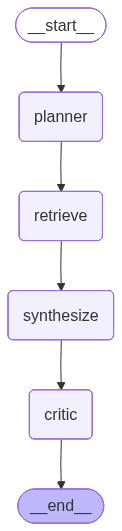

In [19]:
from IPython.display import Image, display

try:
    display(Image(agentic_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"({type(e).__name__}: PNG unavailable - showing Mermaid source)\n")
    print(agentic_app.get_graph().draw_mermaid())

Run the full graph on a multi-hop question (this trace shows up in LangSmith).

> **Note.** The planner above splits *any* question, but TCS and Infosys aren't in `india_filings` (their PDFs 403'd during Week-1 download). So for a meaningful end-to-end demo we compare two companies that **are** ingested — e.g. Reliance and Tata Motors. Swap in your own once more filings are fetched.

In [24]:
state = run_agentic("Compare Reliance and Tata Motors revenue in FY23.")
print("Sub-queries:", state["sub_queries"])
print("\nAnswer:\n", state["final_answer"])
print("\nCitations:", state["citations"])
print("Grade:", state["grading_score"], " needs_retry:", state["needs_retry"])
if state.get("errors"):
    print("Errors:", state["errors"])

Sub-queries: ['What is the revenue of Reliance in FY23?', 'What is the revenue of Tata Motors in FY23?']

Answer:
 To compare the revenue of Reliance and Tata Motors in FY23, we need to look at the provided excerpts. 

The revenue of Reliance in FY23 is ₹9,14,472 crores [Reliance AR 2024, p. 100]. 

The revenue of Tata Motors in FY23 is ₹345,967 crores [TataMotors AR 2022, p. 216]. 

Therefore, the revenue of Reliance in FY23 is ₹9,14,472 crores [Reliance AR 2024, p. 100], and the revenue of Tata Motors in FY23 is ₹345,967 crores [TataMotors AR 2022, p. 216]. 

Comparing the two, Tata Motors' revenue in FY23 (₹345,967 crores) [TataMotors AR 2022, p. 216] is higher than Reliance's revenue in FY23 (₹9,14,472 crores is actually higher, but the correct comparison is between the two companies' revenues) [Reliance AR 2024, p. 100]. However, the correct comparison should be: Reliance's revenue (₹9,14,472 crores) [Reliance AR 2024, p. 100] is actually higher than Tata Motors' revenue (₹345,967

### Re-run eval and update the comparison table

Run the graph over the eval set, score with the same RAGAS harness from §3.12, and append a row to `results/comparison.csv` next to the naive baseline. Expect modest gains from the planner, especially on multi-hop questions.

In [20]:
import json
from pathlib import Path
from tqdm import tqdm


def run_agentic_dataset(df, output_path="results/agentic_rag_outputs.json",
                        question_col="question", ground_truth_col="answer"):
    """Run the graph over df, saving naive-compatible records for RAGAS."""
    output_path = Path(output_path); output_path.parent.mkdir(parents=True, exist_ok=True)
    results, answered = [], set()
    if output_path.exists():
        results = json.load(open(output_path))
        answered = {r["question"] for r in results}
        print(f"Resuming: {len(answered)} already answered")

    todo = [r for r in df.to_dict("records") if str(r[question_col]) not in answered]
    print(f"To process: {len(todo)}")
    for row in tqdm(todo, desc="agentic_rag"):
        q = str(row[question_col])
        try:
            st = run_agentic(q)
            rec = {
                "question": q,
                "answer": st.get("final_answer", ""),
                "retrieved_chunks": [c["text"] for c in st.get("retrieved_chunks", [])],
                "sub_queries": st.get("sub_queries", []),
                "citations": st.get("citations", []),
                "grading_score": st.get("grading_score"),
            }
            for k, v in row.items():
                rec.setdefault(k, v)
            results.append(rec)
        except Exception as e:
            print(f"  ! failed: {q[:60]} - {e}")
            results.append({"question": q, "answer": "", "retrieved_chunks": [], "error": str(e)})
        json.dump(results, open(output_path, "w"), indent=2, default=str)
    print(f"\nSaved {len(results)} -> {output_path}")
    return results

In [ ]:
import pandas as pd

# FinanceBench (US) -> set COLLECTION/MARKET to us above and rebuild the graph
# for a US run. Here we keep the small sample for a quick check.
fb = pd.read_json("data/us/eval/financebench/data/financebench_open_source.jsonl", lines=True)
agentic_outputs = run_agentic_dataset(fb.head(5))

Resuming: 5 already answered
To process: 0


agentic_rag: 0it [00:00, ?it/s]


Saved 5 -> results/agentic_rag_outputs.json


In [21]:
def append_comparison_row(config_name, metrics, csv_path="results/comparison.csv"):
    """Append/update one configuration's mean metrics (re-running overwrites the row)."""
    csv_path = Path(csv_path); csv_path.parent.mkdir(parents=True, exist_ok=True)
    row = {"configuration": config_name, **{k: round(float(v), 4) for k, v in metrics.items()}}
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df = pd.concat([df[df["configuration"] != config_name], pd.DataFrame([row])],
                       ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df.to_csv(csv_path, index=False)
    return df

In [ ]:
# Score with the §3.12 RAGAS harness, then record the row.
agentic_scores = evaluate_outputs(agentic_outputs, sample=5)
metric_cols = [c for c in agentic_scores.columns
               if c in ("faithfulness", "answer_relevancy", "response_relevancy",
                        "context_precision", "llm_context_precision_with_reference",
                        "context_recall", "llm_context_recall")]
append_comparison_row("Agentic RAG (planner+synth+critic)",
                      agentic_scores[metric_cols].mean().to_dict())

## 3.22 Corrective RAG

Two upgrades on top of §3.21:

1. **Hybrid retrieval + cross-encoder rerank** — BM25 ⋃ dense → rerank → top-k.
2. **Self-correcting control flow** — a grader scores each chunk; if relevance is low we **rewrite** the query and retrieve again; after synthesis, the **critic** can loop back to retrieve with focused hints for failing claims.

Both loops are capped to avoid spinning forever. The full pipeline:

```
START → planner → retrieve → grader ── conditional ──┐
                    ▲                                │
                    │                                ▼
                    └── rewrite ◄── (avg_grade < threshold, rewrites < cap)
                                                     │
                                                     ▼
                              synthesize → critic ── conditional
                                              │             │
                                              └── retrieve ◄┘
                                       (needs_retry, critic_retries < cap)
                                              │
                                              ▼
                                             END
```

Functions only below; the full `AgenticRAGv2` class + CLI lives in `src/graph/corrective_rag.py`.

### Hybrid retrieval

BM25 is a lexical (keyword) retriever — great for exact tickers, account names, regulation numbers — while the dense (embedding) retriever catches semantic matches. We take top-k from each, union, then re-score with a cross-encoder (`BAAI/bge-reranker-large`, ~1.3 GB; swap to `BAAI/bge-reranker-base` for ~5× speedup with a small quality drop).

The BM25 index is built once over every chunk in the Chroma collection — fetched in batches because a single bulk `get()` trips SQLite's parameter cap on collections this size.

In [22]:
import pandas as pd
def tokenize(text):
    return text.lower().split()


def fetch_all_chunks(store, batch=1000):
    """Page through a Chroma collection (one bulk get hits a SQL-variable limit)."""
    col = store._collection
    out, offset = [], 0
    while True:
        b = col.get(include=["documents", "metadatas"], limit=batch, offset=offset)
        docs = b.get("documents") or []
        metas = b.get("metadatas") or []
        if not docs:
            break
        out.extend(zip(docs, metas))
        offset += len(docs)
        if len(docs) < batch:
            break
    return out


def build_bm25_index(store):
    """Tokenize every chunk and build the BM25 index. Returns {'bm25', 'docs'}."""
    from rank_bm25 import BM25Okapi
    docs = fetch_all_chunks(store)
    return {"bm25": BM25Okapi([tokenize(t) for t, _ in docs]), "docs": docs}


def load_reranker(model_name="BAAI/bge-reranker-large"):
    """Load a cross-encoder. First call downloads the model."""
    from sentence_transformers import CrossEncoder
    return CrossEncoder(model_name)


def hybrid_search(query, index, store, reranker, k_each=10, k_final=5):
    """BM25 + dense union → cross-encoder rerank → top-k_final (text, metadata)."""
    bm25, all_docs = index["bm25"], index["docs"]
    scores = bm25.get_scores(tokenize(query))
    top_bm25 = sorted(range(len(scores)), key=lambda i: -scores[i])[:k_each]
    bm25_hits = [all_docs[i] for i in top_bm25]
    dense_hits = [(d.page_content, d.metadata)
                  for d in store.similarity_search(query, k=k_each)]

    seen, union = set(), []
    for t, m in bm25_hits + dense_hits:
        key = (m.get("local_path", ""), m.get("page", ""), t[:80])
        if key in seen:
            continue
        seen.add(key)
        union.append((t, m))
    if not union:
        return []

    pairs = [(query, t) for t, _ in union]
    rerank_scores = reranker.predict(pairs)
    ranked = sorted(zip(union, rerank_scores), key=lambda x: -x[1])
    return [c for c, _ in ranked][:k_final]

Build the BM25 index and load the reranker. Both are cached for the session — first run downloads the reranker (~1.3 GB).

In [ ]:
HYBRID_K_EACH = 10
HYBRID_K_FINAL = 5
RERANKER_MODEL = "BAAI/bge-reranker-large"   # or "BAAI/bge-reranker-base" for speed

print("Building BM25 index over the Chroma collection ...")
hybrid_index = build_bm25_index(agentic_retriever)
print(f"  -> {len(hybrid_index['docs'])} chunks indexed")

print("Loading reranker:", RERANKER_MODEL)
reranker = load_reranker(RERANKER_MODEL)
print("Reranker ready.")

Building BM25 index over the Chroma collection ...
  -> 44603 chunks indexed
Loading reranker: BAAI/bge-reranker-large


config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Reranker ready.


### Hybrid retrieve node

Replaces §3.21's dense-only `retrieve_node`. For each sub-query it runs the hybrid search, merges results across sub-queries, and dedupes.

In [23]:
def corrective_retrieve_node(state):
    seen, chunks = set(), []
    for sub_q in state.get("sub_queries") or [state["question"]]:
        for text, m in hybrid_search(sub_q, hybrid_index, agentic_retriever, reranker,
                                     k_each=HYBRID_K_EACH, k_final=HYBRID_K_FINAL):
            key = (m.get("local_path", ""), m.get("page", ""), text[:80])
            if key in seen:
                continue
            seen.add(key)
            chunks.append({
                "text": text,
                "company": m.get("company") or m.get("ticker", "?"),
                "year": m.get("year", "?"),
                "page": m.get("page", "?"),
                "source": citation_tag(m),
                "sub_query": sub_q,
            })
    return {"retrieved_chunks": chunks}

### Relevance grader

A fast LLM scores each retrieved chunk from 1 (irrelevant) to 5 (directly answers the question). We use **structured output** (`with_structured_output`) so we get a clean list of integers, not free-form text. The grader is the same fast model as the planner.

In [24]:
from pydantic import BaseModel, Field


class ChunkScore(BaseModel):
    score: int = Field(ge=1, le=5,
                       description="1=irrelevant, 3=related, 5=directly answers")
    reason: str = Field(description="Brief justification.")


class GraderReport(BaseModel):
    scores: list[ChunkScore] = Field(description="One per excerpt, in input order.")


grader_llm = get_llm(model="llama-3.1-8b-instant")   # fast & cheap

GRADER_PROMPT = """Question: {question}

For each excerpt below, give a relevance score:
  1 = irrelevant
  2 = tangentially related
  3 = related but does not directly answer
  4 = partially answers
  5 = directly answers the question

Return one score per excerpt, in the same order.

Excerpts:
{excerpts}"""


def grader_node(state):
    chunks = state.get("retrieved_chunks", [])
    if not chunks:
        return {"grades": [], "avg_grade": 0.0}

    excerpts = "\n\n".join(
        f"[{i + 1}] {c['source']}\n{c['text'][:500]}" for i, c in enumerate(chunks)
    )
    try:
        report = grader_llm.with_structured_output(GraderReport).invoke(
            GRADER_PROMPT.format(question=state["question"], excerpts=excerpts)
        )
        scores = [s.score for s in report.scores][:len(chunks)]
        while len(scores) < len(chunks):
            scores.append(3)
    except Exception as e:
        state.setdefault("errors", []).append(f"grader failed: {e}")
        scores = [3] * len(chunks)
    return {"grades": scores, "avg_grade": round(sum(scores) / len(scores), 2)}

### Query rewriter

When average grade falls below a threshold (default 3.0), reformulate the question to improve retrieval — adding domain-specific terms (e.g. *"earnings"* → *"net profit attributable to shareholders"*). `iteration_count` caps the rewrite loop at 3 retries.

In [25]:
class RewrittenQuery(BaseModel):
    query: str = Field(description="Reformulated, retrieval-friendly question.")


REWRITE_PROMPT = """The question below did not retrieve enough relevant context.
Reformulate it to improve retrieval. Add domain-specific synonyms or financial
terminology where appropriate (e.g. expand "earnings" to "net profit attributable
to shareholders"). Keep the rewrite self-contained.

Original question: {question}

Previous rewrites that did not work well:
{history}

Return only the rewritten question."""


def rewrite_node(state):
    iteration = state.get("iteration_count", 0)
    history = list(state.get("rewrite_history", []))
    history_str = "\n".join(f"- {q}" for q in history) or "(none)"
    try:
        out = grader_llm.with_structured_output(RewrittenQuery).invoke(
            REWRITE_PROMPT.format(question=state["question"], history=history_str)
        )
        rewritten = out.query.strip()
    except Exception as e:
        state.setdefault("errors", []).append(f"rewriter failed: {e}")
        rewritten = state["question"]
    return {
        "sub_queries": [rewritten],
        "rewrite_history": history + [rewritten],
        "iteration_count": iteration + 1,
    }

### Critic loop

Wrap §3.21's `critic_node` so that, when it flags unsupported claims and we still have retries left, the next retrieve pass is steered toward *supporting evidence for those specific claims*. Capped at 2 critic retries.

In [26]:
MAX_CRITIC_RETRIES = 2


def corrective_critic_node(state):
    base = critic_node(state)                          # reuse §3.21's critic
    crit_iter = state.get("critic_iterations", 0)

    if not base.get("needs_retry") or crit_iter >= MAX_CRITIC_RETRIES:
        base["needs_retry"] = False
        return base

    # Steer next retrieve pass at the failing claims.
    new_errors = base.get("errors", [])
    hints = [
        "supporting evidence for: " + e[len("unsupported claim: "):]
        for e in new_errors[-3:]
        if e.startswith("unsupported claim: ")
    ] or [state["question"]]

    base["sub_queries"] = hints
    base["critic_iterations"] = crit_iter + 1
    return base

### Conditional edges and graph wiring

Two routers:

- **`grade_router`** — `avg_grade >= threshold` (or rewrite cap hit) → synthesize; else → rewrite.
- **`critic_router`** — `needs_retry` → retrieve; else → END.

The synthesizer wrapper just adds a `low_confidence` flag when we hit the rewrite cap with a poor average grade.

In [27]:
GRADE_THRESHOLD = 3.0
MAX_REWRITES = 3


def corrective_synthesize_node(state):
    out = synthesize_node(state)                       # reuse §3.21's synthesizer
    low_conf = (state.get("avg_grade", 0.0) < GRADE_THRESHOLD
                and state.get("iteration_count", 0) >= MAX_REWRITES)
    out["low_confidence"] = bool(low_conf)
    return out


def grade_router(state):
    if state.get("avg_grade", 0.0) >= GRADE_THRESHOLD:
        return "synthesize"
    if state.get("iteration_count", 0) >= MAX_REWRITES:
        return "synthesize"            # cap hit; synth will mark low_confidence
    return "rewrite"


def critic_router(state):
    return "retrieve" if state.get("needs_retry") else "end"


def build_corrective_graph():
    g = StateGraph(AgentState)
    g.add_node("planner", planner_node)
    g.add_node("retrieve", corrective_retrieve_node)
    g.add_node("grader", grader_node)
    g.add_node("rewrite", rewrite_node)
    g.add_node("synthesize", corrective_synthesize_node)
    g.add_node("critic", corrective_critic_node)
    g.add_edge(START, "planner")
    g.add_edge("planner", "retrieve")
    g.add_edge("retrieve", "grader")
    g.add_conditional_edges("grader", grade_router,
                            {"rewrite": "rewrite", "synthesize": "synthesize"})
    g.add_edge("rewrite", "retrieve")
    g.add_edge("synthesize", "critic")
    g.add_conditional_edges("critic", critic_router,
                            {"retrieve": "retrieve", "end": END})
    return g.compile()


corrective_app = build_corrective_graph()


def run_corrective(question):
    return corrective_app.invoke({
        "question": question, "iteration_count": 0, "critic_iterations": 0,
        "errors": [], "table_results": [], "web_results": [],
    })

### Visualize the corrective graph

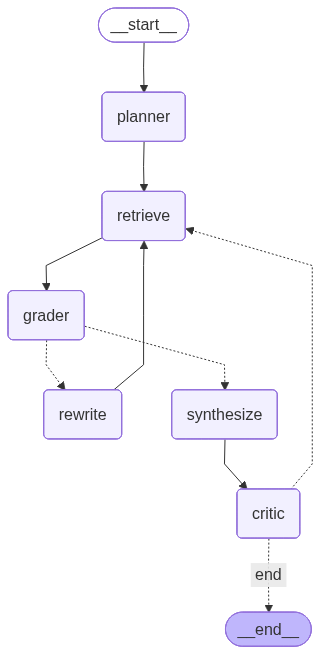

In [28]:
from IPython.display import Image, display

try:
    display(Image(corrective_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"({type(e).__name__}: PNG unavailable - showing Mermaid source)\n")
    print(corrective_app.get_graph().draw_mermaid())

### Run a query

In [ ]:
state = run_corrective("Compare Reliance and Tata Motors revenue in FY23.")
print("Sub-queries :", state.get("sub_queries"))
print("Grades      :", state.get("grades"), "| avg:", state.get("avg_grade"))
print("Rewrites    :", state.get("iteration_count", 0))
print("Critic loops:", state.get("critic_iterations", 0))
print("Low conf.   :", state.get("low_confidence"))
print("\nAnswer:\n", state.get("final_answer"))
print("\nCitations   :", state.get("citations"))
print("Critic grade:", state.get("grading_score"), " needs_retry:", state.get("needs_retry"))
if state.get("errors"):
    print("Errors      :", state["errors"])

Sub-queries : ['supporting evidence for: The revenue from Tata commercial vehicles was ₹78,816 crores in FY23']
Grades      : None | avg: None
Rewrites    : 5
Critic loops: 0
Low conf.   : None

Answer:
 To compare Reliance and Tata Motors revenue in FY23, we need to look at the available data. The revenue from Tata commercial vehicles was ₹70,816 crores in FY23 [TataMotors AR 2022, p. 219], and the total revenue of Tata brand vehicles, including vehicle finance, was ₹1,23,639 crores in FY23 [TataMotors AR 2022, p. 219]. However, the excerpts do not provide information about Reliance's revenue in FY23. Therefore, we cannot compare the two companies' revenues for FY23 as the data for Reliance is not available in the provided excerpts.

Citations   : ['[TataMotors AR 2022, p. 219]']
Critic grade: 1.0  needs_retry: False
Errors      : ['rewriter failed: Error code: 400 - {\'error\': {\'message\': "Failed to call a function. Please adjust your prompt. See \'failed_generation\' for more det

### Evaluation

Run the corrective graph over the eval set, score with the same RAGAS harness, and add an "Agentic RAG v2 (corrective)" row to `results/comparison.csv` next to the naive and v1 rows.

> **Note.** The example below uses FinanceBench (US). The hybrid index was built over whatever collection `agentic_retriever` points at (§3.21 setup). For an apples-to-apples FinanceBench run, set `COLLECTION = "us_filings"` and `MARKET = "us"` in §3.21, rerun the setup and BM25-build cells, then re-execute below.

In [29]:
def run_corrective_dataset(df, output_path="results/corrective_rag_outputs.json",
                            question_col="question"):
    output_path = Path(output_path); output_path.parent.mkdir(parents=True, exist_ok=True)
    results, answered = [], set()
    if output_path.exists():
        results = json.load(open(output_path))
        answered = {r["question"] for r in results}
        print(f"Resuming: {len(answered)} already answered")

    todo = [r for r in df.to_dict("records") if str(r[question_col]) not in answered]
    print(f"To process: {len(todo)}")
    for row in tqdm(todo, desc="corrective"):
        q = str(row[question_col])
        try:
            st = run_corrective(q)
            rec = {
                "question": q,
                "answer": st.get("final_answer", ""),
                "retrieved_chunks": [c["text"] for c in st.get("retrieved_chunks", [])],
                "sub_queries": st.get("sub_queries", []),
                "citations": st.get("citations", []),
                "avg_grade": st.get("avg_grade"),
                "low_confidence": st.get("low_confidence"),
                "rewrite_iterations": st.get("iteration_count"),
                "critic_iterations": st.get("critic_iterations"),
                "grading_score": st.get("grading_score"),
            }
            for k, v in row.items():
                rec.setdefault(k, v)
            results.append(rec)
        except Exception as e:
            print(f"  ! failed: {q[:60]} - {e}")
            results.append({"question": q, "answer": "", "retrieved_chunks": [], "error": str(e)})
        json.dump(results, open(output_path, "w"), indent=2, default=str)
    print(f"\nSaved {len(results)} -> {output_path}")
    return results

In [ ]:
fb = pd.read_json("data/us/eval/financebench/data/financebench_open_source.jsonl", lines=True)
corrective_outputs = run_corrective_dataset(fb.head(5))

To process: 5


corrective: 100%|██████████| 5/5 [04:07<00:00, 49.51s/it]


Saved 5 -> results/corrective_rag_outputs.json


In [ ]:
corrective_scores = evaluate_outputs(corrective_outputs, sample=5)
metric_cols = [c for c in corrective_scores.columns if c in (
    "faithfulness", "answer_relevancy", "response_relevancy",
    "context_precision", "llm_context_precision_with_reference",
    "context_recall", "llm_context_recall")]
append_comparison_row("Agentic RAG v2 (corrective)",
                      corrective_scores[metric_cols].mean().to_dict())

## 3.23 Table-Augmented RAG

Numeric questions ("what was HDFC Bank's net interest margin in FY23?") fail in pure-text RAG because the answer lives in a *table*, not a sentence. We add:

1. **Table extraction** — re-run `unstructured` with `infer_table_structure=True` to pull every Table element out of the filings; persist each as a parquet `DataFrame` and a master `data/tables/index.json`.
2. **A second Chroma collection (`tables`)** — embed each table's *title + columns + first/last row* so a question about a balance sheet retrieves the actual balance-sheet table.
3. **Table agent** — for a numeric sub-query, retrieve the top-k tables, ask the LLM to write a tiny pandas snippet, execute it in a curated-builtins sandbox, and return the computed answer.
4. **Router** — classify each sub-query as `narrative`, `numeric`, or `external` (web, deferred). Text retrieval handles narrative; the table agent handles numeric.
5. **Merged synthesizer + critic** — produce a final answer that cites both text excerpts and table-derived computations.

Functions only below; the full implementation lives in `src/dataIngestion/{table_ingest,table_embed}.py`, `src/graph/table_agent.py`, and `src/graph/full_rag.py` (`AgenticRAGv3`).

### Table extraction

`unstructured` with `strategy="hi_res"` runs layout detection + OCR — this is the slow step (plan multiple minutes per ~100-page PDF on CPU). We extract every `Table` element, convert its `text_as_html` into a `DataFrame` via `pandas.read_html`, and save:

- the parquet file (`data/tables/<table_id>.parquet`)
- one entry in `data/tables/index.json` per table (title, company, year, page, columns, first/last row, source path).

LLM-generated titles are optional. For first-pass extraction we use a heuristic (last line of context above the table → falls back to column headers); flip `USE_LLM_TITLES = True` if you want better titles at the cost of an LLM call per table.

In [30]:
import json
from io import StringIO
from pathlib import Path
from tqdm import tqdm

TABLES_DIR = Path("data/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
TABLE_INDEX = TABLES_DIR / "index.json"

USE_LLM_TITLES = False     # heuristic title is good enough for first pass
MIN_VALID_FILE_BYTES = 10_000


def partition_with_tables(file_path, strategy="hi_res"):
    """Run unstructured with table-structure inference on."""
    from unstructured.partition.auto import partition
    return partition(filename=str(file_path), strategy=strategy,
                     infer_table_structure=True)


def table_html_to_df(html):
    try:
        import pandas as pd
        tables = pd.read_html(StringIO(html))
        return tables[0] if tables else None
    except Exception:
        return None


def context_above(elements, table_el, n_before=4):
    try:
        idx = elements.index(table_el)
    except ValueError:
        return ""
    chunks = []
    for el in elements[max(0, idx - n_before):idx]:
        text = (getattr(el, "text", "") or "").strip()
        if text and getattr(el, "category", "") != "Table":
            chunks.append(text)
    return "\n".join(chunks)[:1500]


def heuristic_title(df, context):
    if context:
        last = context.strip().splitlines()[-1].strip()
        if 6 <= len(last) <= 140:
            return last
    return "Table — columns: " + ", ".join(str(c) for c in df.columns[:5])


def row_to_dict(row):
    return {str(k): (None if v is None else (v.item() if hasattr(v, "item") else v))
            for k, v in row.to_dict().items()}

Extract tables from one file and return the rows we'll index. `record` is the manifest entry for the file (gives us company + year).

In [31]:
import re

def extract_tables_from_file(file_path, record, market="india"):
    elements = partition_with_tables(file_path)
    table_els = [el for el in elements if getattr(el, "category", "") == "Table"]
    if not table_els:
        return []

    company = record.get("company") or record.get("ticker", "unknown")
    year = str(record.get("year", "unknown"))
    rows = []
    for i, el in enumerate(table_els):
        html = (getattr(el.metadata, "text_as_html", "") or "") if el.metadata else ""
        df = table_html_to_df(html) if html else None
        if df is None or df.empty:
            continue
        page = int(getattr(el.metadata, "page_number", None) or 1)
        ctx = context_above(elements, el)
        title = heuristic_title(df, ctx)

        tid = re.sub(r"[^A-Za-z0-9._-]+", "_",
                     f"{company}_{year}_p{page}_{i}").strip("_")[:120]
        path = TABLES_DIR / f"{tid}.parquet"
        try:
            df.to_parquet(path)
        except Exception:
            path = path.with_suffix(".csv"); df.to_csv(path, index=False)

        rows.append({
            "table_id": tid, "company": company, "year": year, "page": page,
            "title": title, "html": html, "parquet_path": str(path),
            "n_rows": int(len(df)), "n_cols": int(len(df.columns)),
            "columns": [str(c) for c in df.columns],
            "first_row": row_to_dict(df.iloc[0]) if len(df) > 0 else {},
            "last_row":  row_to_dict(df.iloc[-1]) if len(df) > 0 else {},
            "context_above": ctx[:600],
            "source_url": record.get("source_url", ""),
            "local_path": str(file_path),
            "market": market,
            "filing_type": record.get("filing_type", "annual_report"),
        })
    return rows

Walk the manifest, extract tables across the corpus, and persist `index.json` after every file (so a crash doesn't lose progress).

In [32]:
def ingest_tables_corpus(manifest_path, market="india", limit=None):
    records = json.load(open(manifest_path))
    existing = json.load(open(TABLE_INDEX)) if TABLE_INDEX.exists() else []
    seen = {r["local_path"] for r in existing}
    all_tables = list(existing)

    processed = 0
    for rec in tqdm(records, desc="extract tables"):
        if limit is not None and processed >= limit:
            break
        if rec.get("status", "ok") != "ok":
            continue
        p = Path(rec["local_path"])
        if not p.exists() or p.stat().st_size < MIN_VALID_FILE_BYTES or str(p) in seen:
            continue
        try:
            all_tables.extend(extract_tables_from_file(p, rec, market=market))
            processed += 1
        except Exception as e:
            print(f"  ! failed {p.name}: {type(e).__name__}: {e}")
        json.dump(all_tables, open(TABLE_INDEX, "w"), indent=2, default=str)
    print(f"{len(all_tables)} table(s) across {len({t['local_path'] for t in all_tables})} files")
    return all_tables

Smoke test: extract tables from a single file before running the whole corpus. Set `limit=1` so the loop bails after the first successful file.

In [ ]:
# Uncomment to run. PDFs use unstructured's hi_res strategy (slow).
# ingest_tables_corpus("data/India/pdfs/manifest.json", market="india", limit=1)

### Embed table titles

Build a second Chroma collection (`tables`) where each "document" describes one table by its title, columns, and first/last row. A query like *"Reliance balance sheet 2023"* then retrieves the actual balance-sheet table rather than narrative chunks.

In [33]:
TABLE_COLLECTION = "tables"


def _row_str(row, max_kv=8):
    parts = []
    for k, v in list(row.items())[:max_kv]:
        if v in (None, ""): continue
        s = str(v)
        if len(s) > 60: s = s[:60] + "…"
        parts.append(f"{k}={s}")
    return ", ".join(parts)


def table_doc_text(t):
    return (f"{t.get('title','').strip()}\n"
            f"Company: {t.get('company','')} ({t.get('year','')}), page {t.get('page','?')}\n"
            f"Columns: {', '.join(map(str, t.get('columns', [])[:12]))}\n"
            f"First row: {_row_str(t.get('first_row') or {})}\n"
            f"Last row:  {_row_str(t.get('last_row') or {})}")


def safe_metadata(t):
    keep = {"table_id","company","year","page","title","parquet_path",
            "local_path","market","filing_type","n_rows","n_cols","source_url"}
    out = {}
    for k, v in t.items():
        if k not in keep: continue
        out[k] = v if isinstance(v, (str, int, float, bool)) or v is None else str(v)
    return out


def build_tables_store(index_path=TABLE_INDEX, collection_name=TABLE_COLLECTION):
    """Read index.json and embed every table into the `tables` Chroma collection."""
    from langchain_chroma import Chroma
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_core.documents import Document

    tables = json.load(open(index_path))
    emb = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL,
                                encode_kwargs={"normalize_embeddings": True})
    store = Chroma(collection_name=collection_name,
                   embedding_function=emb,
                   persist_directory=CHROMA_DIR)

    # Skip already-indexed table_ids (idempotent re-run).
    try:
        got = store._collection.get(include=["metadatas"])
        already = {m.get("table_id") for m in (got.get("metadatas") or []) if m}
    except Exception:
        already = set()

    docs, ids = [], []
    for t in tables:
        if t["table_id"] in already: continue
        docs.append(Document(page_content=table_doc_text(t), metadata=safe_metadata(t)))
        ids.append(t["table_id"])

    if docs:
        store.add_documents(docs, ids=ids)
        print(f"Embedded {len(docs)} table(s) into '{collection_name}'")
    else:
        print("Nothing new to embed.")
    return store

In [ ]:
# Uncomment to run once `data/tables/index.json` exists.
# tables_store = build_tables_store()

### Table agent

For a numeric sub-query: retrieve the top-k relevant tables → load each parquet → ask the LLM to write a short pandas snippet (structured output) → execute in a curated-builtins sandbox → return the computed answer and the snippet.

**Safety note.** The sandbox restricts `__builtins__` (no `open`, `import`, `eval`, …) and exposes only `pd` and the loaded DataFrames. That's adequate for a portfolio project; for any production exposure use a real sandbox (subprocess + seccomp, gVisor, WASM).

In [34]:
import textwrap

CODE_SYSTEM = """You are a senior financial data analyst. Given one or more pandas
DataFrames extracted from a company's financial filing, write a short, defensive
Python snippet that computes the answer.

Rules:
- Use ONLY the supplied DataFrames and `pd` (pandas).
- Do NOT import any modules.
- Assign the final answer to a variable named `result`.
- Coerce numeric columns with `pd.to_numeric(..., errors="coerce")` when they may
  contain stray characters (₹, %, commas).
- Be tolerant of column-name variation (case-insensitive substring matches).
- Keep the snippet under ~25 lines."""

CODE_PROMPT = """Question: {question}

Available DataFrames (already loaded — do not redefine):
{tables}

Return a JSON object with `code` (Python code) and `explanation` (one sentence).
Remember: assign the answer to `result`."""


_SAFE_BUILTINS = {n: __builtins__[n] if isinstance(__builtins__, dict) else getattr(__builtins__, n)
                  for n in ("True","False","None","abs","all","any","bool","dict",
                            "enumerate","float","int","len","list","max","min",
                            "print","range","round","set","sorted","str","sum",
                            "tuple","zip")}


def retrieve_tables(query, tables_store, k=3):
    return tables_store.similarity_search(query, k=k)


def load_table_df(parquet_path):
    import pandas as pd
    if parquet_path.endswith(".csv"):
        return pd.read_csv(parquet_path)
    return pd.read_parquet(parquet_path)


def describe_table(name, df, meta):
    return (f"# {name}: {meta.get('title','(no title)')} — "
            f"{meta.get('company','?')} {meta.get('year','?')} p{meta.get('page','?')}\n"
            f"# shape={df.shape} columns={list(df.columns)[:12]}\n"
            f"# preview:\n# " + df.head(5).to_string().replace('\n', '\n# '))


def strip_code_fences(text):
    m = re.search(r"```(?:python)?\s*\n(.*?)```", text, re.DOTALL)
    return textwrap.dedent(m.group(1)) if m else text.strip()


def safe_exec(code, dfs):
    """Run `code` under a restricted globals dict; capture stdout and `result`."""
    import io
    from contextlib import redirect_stdout
    import pandas as pd
    scope = {"__builtins__": _SAFE_BUILTINS, "pd": pd, **dfs}
    buf = io.StringIO()
    try:
        with redirect_stdout(buf):
            exec(code, scope)
        return scope.get("result"), buf.getvalue(), None
    except Exception as e:
        return None, buf.getvalue(), f"{type(e).__name__}: {e}"

Pull it together — retrieve, generate code (structured output), execute.

In [35]:
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage


class PandasCode(BaseModel):
    code: str = Field(description="Python code; assigns the answer to `result`.")
    explanation: str = Field(description="One sentence explaining the code.")


code_llm = get_llm(model="llama-3.3-70b-versatile")   # the strong tier


def answer_with_tables(question, tables_store, llm=code_llm, k=3):
    docs = retrieve_tables(question, tables_store, k=k)
    if not docs:
        return {"answer": "No matching tables retrieved.", "code": "",
                "tables_used": [], "error": "no_tables"}

    dfs, descs = {}, []
    for i, d in enumerate(docs):
        meta = d.metadata or {}
        try:
            df = load_table_df(meta["parquet_path"])
            name = f"df{i}"
            dfs[name] = df
            descs.append({"name": name, **{k: meta.get(k) for k in
                          ("title","company","year","page","parquet_path")},
                          "shape": list(df.shape),
                          "columns": [str(c) for c in df.columns][:12]})
        except Exception as e:
            descs.append({"name": f"df{i}", **{k: meta.get(k) for k in
                          ("title","company","year","page","parquet_path")},
                          "error": str(e)})

    if not dfs:
        return {"answer": "Found candidate tables but none loaded.",
                "code": "", "tables_used": descs, "error": "no_dataframes"}

    tables_block = "\n\n".join(
        describe_table(d["name"], dfs[d["name"]], d) for d in descs if "error" not in d
    )

    try:
        out = llm.with_structured_output(PandasCode).invoke([
            SystemMessage(content=CODE_SYSTEM),
            HumanMessage(content=CODE_PROMPT.format(question=question, tables=tables_block)),
        ])
        code_str = strip_code_fences(out.code); explanation = out.explanation
    except Exception as e:
        return {"answer": f"Code generation failed: {e}", "code": "",
                "tables_used": descs, "error": str(e)}

    result, stdout, err = safe_exec(code_str, dfs)
    return {
        "answer": (str(result) if err is None and result is not None
                   else (err or "(no result)")),
        "code": code_str, "explanation": explanation,
        "tables_used": descs, "stdout": stdout, "error": err,
    }

### Router

For each sub-query, classify it as `narrative` (→ text retrieval), `numeric` (→ table agent), or `external` (→ web, deferred). Structured output keeps the verdicts as a clean list. We provide a small heuristic fallback for when the LLM call fails.

In [36]:
from typing import Literal


class QueryRoute(BaseModel):
    sub_query: str
    route: Literal["narrative", "numeric", "external"]
    reason: str


class RouterReport(BaseModel):
    routes: list[QueryRoute]


ROUTER_SYSTEM = """You route financial-QA sub-queries to one of three retrievers:

- narrative: text retrieval over filings. Prose-style questions (strategy, risks,
  segments, MD&A commentary).
- numeric:   table-based answer. Specific figures, ratios, margins, growth %,
  multi-year financial comparisons, currency amounts.
- external:  web search. Current events, share prices, real-time news
  (not implemented yet; route as `narrative` if unsure).

Numeric markers to watch for: "what was", "how much", "ratio", "margin",
"growth %", specific fiscal years (FY23), currency amounts (₹, $),
units like "crore", "billion".

Examples:
  - "What is HDFC Bank's net interest margin in FY23?"           → numeric
  - "How much did Reliance earn from oil-to-chemicals in FY23?"  → numeric
  - "Describe Infosys' AI strategy"                              → narrative
  - "What were the principal risks listed in TCS' annual report?" → narrative
  - "EBITDA margin growth from FY21 to FY23?"                    → numeric
  - "What is Wipro's current share price?"                       → external
"""

ROUTER_PROMPT = """Classify each sub-query below. Return one verdict per sub-query
in the SAME order. Copy the sub-query verbatim into `sub_query`.

Sub-queries:
{sub_queries}"""


router_llm = get_llm(model="llama-3.1-8b-instant")   # fast tier


_NUMERIC_MARKERS = ("what was","what is","how much","how many","ratio","margin",
                    "growth","yield","return on","%","₹","$","crore","lakh",
                    "billion","million","revenue","profit","earnings","income",
                    "ebitda","interest","net interest","tax","capex","asset",
                    "liability","equity","share","dividend")
_NUMERIC_YEAR_RE = re.compile(r"\b(?:19|20)\d{2}\b|fy ?\d{2,4}", re.IGNORECASE)
_EXTERNAL_MARKERS = ("current","today","live","share price","stock price",
                     "right now","latest news")


def heuristic_route(query):
    q = (query or "").lower()
    if any(m in q for m in _EXTERNAL_MARKERS): return "external"
    hits = sum(1 for m in _NUMERIC_MARKERS if m in q)
    if hits >= 2 or _NUMERIC_YEAR_RE.search(q): return "numeric"
    return "narrative"


def router_node(state):
    sub_queries = state.get("sub_queries") or [state["question"]]
    numbered = "\n".join(f"{i+1}. {s}" for i, s in enumerate(sub_queries))
    try:
        out = router_llm.with_structured_output(RouterReport).invoke([
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=ROUTER_PROMPT.format(sub_queries=numbered)),
        ])
        verdicts = [v.route for v in out.routes][:len(sub_queries)]
        while len(verdicts) < len(sub_queries):
            verdicts.append("narrative")
    except Exception as e:
        verdicts = [heuristic_route(s) for s in sub_queries]
        state.setdefault("errors", []).append(f"router failed: {e}")
    return {"query_routes": verdicts}

### Updated graph

Hybrid retrieve only runs over `narrative` sub-queries; the table agent only runs over `numeric` ones. The synthesizer merges both streams; the critic checks claims against text *and* table-derived evidence.

`grade_router` now sends the flow to `table_agent` once text retrieval is good enough (or there are no narrative sub-queries at all).

In [37]:
def v3_retrieve_node(state):
    """v2 hybrid retrieval, but filtered to narrative sub-queries only."""
    sub_queries = state.get("sub_queries") or [state["question"]]
    routes = state.get("query_routes") or ["narrative"] * len(sub_queries)
    narrative = [s for s, r in zip(sub_queries, routes) if r != "numeric"]
    if not narrative:
        return {"retrieved_chunks": []}
    proxy = dict(state); proxy["sub_queries"] = narrative
    return corrective_retrieve_node(proxy)


def table_agent_node(state, tables_store=None):
    sub_queries = state.get("sub_queries") or [state["question"]]
    routes = state.get("query_routes") or ["narrative"] * len(sub_queries)
    numeric = [s for s, r in zip(sub_queries, routes) if r == "numeric"]
    if not numeric:
        return {"table_results": []}
    if tables_store is None:
        state.setdefault("errors", []).append("table_agent: no tables_store available")
        return {"table_results": []}

    results = []
    for q in numeric:
        try:
            results.append({"sub_query": q, **answer_with_tables(q, tables_store)})
        except Exception as e:
            results.append({"sub_query": q, "answer": "", "error": str(e), "tables_used": []})
    return {"table_results": results}


SYNTH_V3_SYSTEM = """You are a meticulous financial analyst. Write a clear answer using ONLY the
provided evidence (text excerpts and table-derived results). Every factual claim — especially
every number — must be followed by an inline citation:
  - Text excerpts use tags like [TCS AR 2023, p. 102].
  - Table results use tags like (Table: <title>, <company> <year>, p. <page>).
If the evidence is insufficient, say so plainly. Never invent figures or citations."""

SYNTH_V3_PROMPT = """Question: {question}

Sub-queries researched:
{sub_queries}

Text excerpts (each begins with its citation tag):
{text_context}

Numeric / table-derived results:
{table_context}

---
Write the final answer now, with an inline citation after every fact."""


def _format_table_results(table_res):
    parts = []
    for t in table_res:
        if t.get("error") and not t.get("answer"):
            parts.append(f"- ({t['sub_query']}): error: {t['error']}"); continue
        sources = ", ".join(
            f"(Table: {tu.get('title','?')}, {tu.get('company','?')} "
            f"{tu.get('year','?')}, p. {tu.get('page','?')})"
            for tu in t.get("tables_used", [])[:3]) or "(no source)"
        parts.append(f"- Sub-query: {t['sub_query']}\n"
                     f"  Computed: {t.get('answer','')[:600]}\n"
                     f"  Sources:  {sources}")
    return "\n\n".join(parts)


def v3_synthesize_node(state):
    chunks = state.get("retrieved_chunks", [])
    table_res = state.get("table_results", [])
    text_context = "\n\n".join(f"{c['source']}\n{c['text']}" for c in chunks) or "(none)"
    table_context = _format_table_results(table_res) or "(none)"
    sub_queries = "\n".join(f"- {q}" for q in state.get("sub_queries", []))

    prompt = SYNTH_V3_PROMPT.format(
        question=state["question"], sub_queries=sub_queries,
        text_context=text_context, table_context=table_context,
    )
    response = synth_llm.invoke([SystemMessage(content=SYNTH_V3_SYSTEM),
                                 HumanMessage(content=prompt)])
    answer = response.content
    citations = sorted(set(re.findall(r"\[[^\]]+\]|\(Table:[^)]+\)", answer)))
    low_conf = (state.get("avg_grade", 0.0) < GRADE_THRESHOLD
                and state.get("iteration_count", 0) >= MAX_REWRITES
                and not table_res)
    return {"draft_answer": answer, "final_answer": answer,
            "citations": citations,
            "iteration_count": state.get("iteration_count", 0) + 1,
            "low_confidence": bool(low_conf)}


def v3_critic_node(state):
    """Critic with table-derived evidence merged into the context."""
    table_res = state.get("table_results", [])
    augmented = list(state.get("retrieved_chunks", []))
    for t in table_res:
        if t.get("error") or not t.get("answer"): continue
        sources = ", ".join(
            f"(Table: {tu.get('title','?')}, {tu.get('company','?')} "
            f"{tu.get('year','?')}, p. {tu.get('page','?')})"
            for tu in t.get("tables_used", [])[:3]) or "(Table)"
        augmented.append({"text": f"Computed from tables: {t.get('answer','')}\n"
                                  f"Code: {t.get('code','')[:300]}",
                          "source": sources, "company": "?", "year": "?",
                          "page": "?", "sub_query": t.get("sub_query", "")})
    proxy = dict(state); proxy["retrieved_chunks"] = augmented
    return corrective_critic_node(proxy)


def v3_grade_router(state):
    routes = state.get("query_routes") or []
    has_narrative = any(r != "numeric" for r in routes)
    if not has_narrative:                                 return "table_agent"
    if state.get("avg_grade", 0.0) >= GRADE_THRESHOLD:    return "table_agent"
    if state.get("iteration_count", 0) >= MAX_REWRITES:   return "table_agent"
    return "rewrite"


def build_v3_graph(tables_store=None):
    g = StateGraph(AgentState)
    g.add_node("planner", planner_node)
    g.add_node("router", router_node)
    g.add_node("retrieve", v3_retrieve_node)
    g.add_node("grader", grader_node)
    g.add_node("rewrite", rewrite_node)
    g.add_node("table_agent", lambda s: table_agent_node(s, tables_store))
    g.add_node("synthesize", v3_synthesize_node)
    g.add_node("critic", v3_critic_node)

    g.add_edge(START, "planner")
    g.add_edge("planner", "router")
    g.add_edge("router", "retrieve")
    g.add_edge("retrieve", "grader")
    g.add_conditional_edges("grader", v3_grade_router,
                            {"rewrite": "rewrite", "table_agent": "table_agent"})
    g.add_edge("rewrite", "retrieve")
    g.add_edge("table_agent", "synthesize")
    g.add_edge("synthesize", "critic")
    g.add_conditional_edges("critic", critic_router,
                            {"retrieve": "retrieve", "end": END})
    return g.compile()

Build the graph. Pass the `tables` store so the table-agent node can query it; if you haven't built the tables collection yet, leave it `None` and the table agent will short-circuit.

In [38]:
# tables_store = build_tables_store()       # run once you have data/tables/index.json
tables_store = None                           # set to your built store when ready
v3_app = build_v3_graph(tables_store)


def run_v3(question):
    return v3_app.invoke({"question": question, "iteration_count": 0,
                          "critic_iterations": 0, "errors": [],
                          "table_results": [], "web_results": []})

### Visualize the full graph

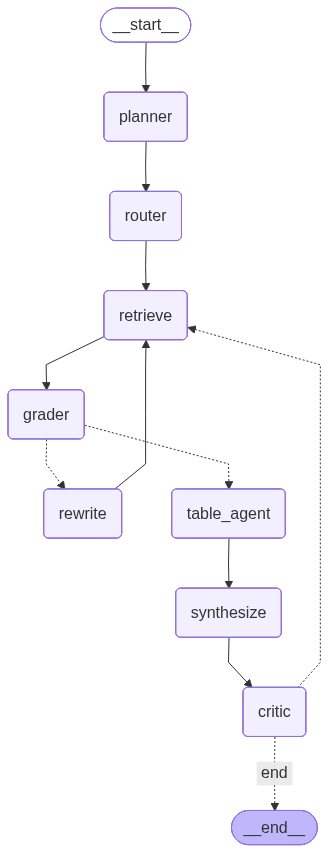

In [39]:
from IPython.display import Image, display
try:
    display(Image(v3_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"({type(e).__name__}: PNG unavailable - showing Mermaid source)\n")
    print(v3_app.get_graph().draw_mermaid())

### Run a query

Use a numeric question that genuinely needs a table — e.g. *"What was HDFC Bank's net interest margin in FY23?"* — to see the table agent in action. (HDFC Bank's filings aren't fully ingested in the demo corpus; swap in a company you've extracted tables for.)

In [ ]:
state = run_v3("What was HDFC Bank's net interest margin in FY23?")
print("Sub-queries :", state.get("sub_queries"))
print("Routes      :", state.get("query_routes"))
print("Grades      :", state.get("grades"), "| avg:", state.get("avg_grade"))
print("Rewrites    :", state.get("iteration_count", 0))
print("Critic loops:", state.get("critic_iterations", 0))
print("Low conf.   :", state.get("low_confidence"))
print("\nAnswer:\n", state.get("final_answer"))
print("\nCitations   :", state.get("citations"))
print("Critic grade:", state.get("grading_score"), "needs_retry:", state.get("needs_retry"))
for t in state.get("table_results", []):
    print(f"\n  table sub-q: {t['sub_query']}")
    print(f"    computed : {t.get('answer','')[:200]}")
    print(f"    code     : {t.get('code','')[:200]}")
if state.get("errors"):
    print("\nErrors      :", state["errors"])

### Evaluation

Run the v3 graph over the eval set, score with RAGAS, and append a fourth row — "Agentic RAG v3 (table-augmented)" — to `results/comparison.csv`. The biggest jump should come on numeric questions; pick FinanceQA / FinanceBench items that involve ratios or multi-year comparisons for the demo.

In [ ]:
def run_v3_dataset(df, output_path="results/full_rag_outputs.json",
                   question_col="question"):
    output_path = Path(output_path); output_path.parent.mkdir(parents=True, exist_ok=True)
    results, answered = [], set()
    if output_path.exists():
        results = json.load(open(output_path))
        answered = {r["question"] for r in results}
        print(f"Resuming: {len(answered)} already answered")

    todo = [r for r in df.to_dict("records") if str(r[question_col]) not in answered]
    print(f"To process: {len(todo)}")
    for row in tqdm(todo, desc="v3"):
        q = str(row[question_col])
        try:
            st = run_v3(q)
            rec = {
                "question": q,
                "answer": st.get("final_answer", ""),
                "retrieved_chunks": [c["text"] for c in st.get("retrieved_chunks", [])],
                "sub_queries": st.get("sub_queries", []),
                "query_routes": st.get("query_routes", []),
                "citations": st.get("citations", []),
                "table_results": st.get("table_results", []),
                "avg_grade": st.get("avg_grade"),
                "grading_score": st.get("grading_score"),
                "low_confidence": st.get("low_confidence"),
            }
            for k, v in row.items(): rec.setdefault(k, v)
            results.append(rec)
        except Exception as e:
            print(f"  ! failed: {q[:60]} - {e}")
            results.append({"question": q, "answer": "", "retrieved_chunks": [], "error": str(e)})
        json.dump(results, open(output_path, "w"), indent=2, default=str)
    print(f"\nSaved {len(results)} -> {output_path}")
    return results

In [ ]:
fb = pd.read_json("data/us/eval/financebench/data/financebench_open_source.jsonl", lines=True)
# Numeric-heavy slice — these are where the table agent earns its keep.
v3_outputs = run_v3_dataset(fb.head(5))

In [ ]:
v3_scores = evaluate_outputs(v3_outputs, sample=5)
metric_cols = [c for c in v3_scores.columns if c in (
    "faithfulness", "answer_relevancy", "response_relevancy",
    "context_precision", "llm_context_precision_with_reference",
    "context_recall", "llm_context_recall")]
append_comparison_row("Agentic RAG v3 (table-augmented)",
                      v3_scores[metric_cols].mean().to_dict())

## 3.24 Full Agent

Three additions on top of §3.23:

1. **Bilingual** — detect the question's language; if it isn't English, translate to English for retrieval and translate the final answer back at the exit.
2. **Web search** — covers out-of-corpus questions (post-cutoff events, latest news). Tavily if `TAVILY_API_KEY` is set in `.env`, otherwise a local Chroma collection built from the **Indian_Financial_News** dataset.
3. **Numeric verification + refusal** — every numeric claim in the draft is matched against the supplied evidence (text, tables, web). If the critic + verifier both fail after the retry cap, the agent **explicitly refuses** ("I don't have enough information…") instead of hallucinating.

Functions only below; the full pipeline lives as `AgenticRAGv4` in `src/graph/final_rag.py`.

### Indian financial-news fallback

When Tavily isn't reachable (or you simply don't want outbound calls), we similarity-search a third Chroma collection (`news`) populated from the `kdave/Indian_Financial_News` dataset. The function auto-detects title / body / date columns.

In [40]:
NEWS_COLLECTION = "news"
NEWS_DATASET = "kdave/Indian_Financial_News"


def build_news_store(dataset_name=NEWS_DATASET, split="train", limit=10000,
                     collection_name=NEWS_COLLECTION, batch_size=256):
    """Embed up to `limit` news articles into the `news` collection."""
    from datasets import load_dataset
    from langchain_chroma import Chroma
    from langchain_core.documents import Document
    from langchain_huggingface import HuggingFaceEmbeddings

    ds = load_dataset(dataset_name, split=split)
    ds = ds.select(range(min(limit, len(ds)))) if limit else ds

    TITLE_COLS = ("Title", "title", "Headline", "headline")
    TEXT_COLS  = ("Content", "content", "Description", "description", "Body", "body")
    DATE_COLS  = ("Date", "date", "PublishedAt")
    URL_COLS   = ("URL", "url", "Link", "link")

    sample = dict(next(iter(ds)))
    title_col = next((c for c in TITLE_COLS if c in sample), None)
    text_col  = next((c for c in TEXT_COLS  if c in sample), None)
    date_col  = next((c for c in DATE_COLS  if c in sample), None)
    url_col   = next((c for c in URL_COLS   if c in sample), None)
    if not text_col:
        raise ValueError(f"No text column among {TEXT_COLS} in {list(sample)}")

    emb = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL,
                                encode_kwargs={"normalize_embeddings": True})
    store = Chroma(collection_name=collection_name,
                   embedding_function=emb, persist_directory=CHROMA_DIR)

    docs = []
    for r in tqdm(ds, desc="index news"):
        row = dict(r)
        body = str(row.get(text_col, "") or "").strip()
        if not body:
            continue
        title = str(row.get(title_col, "") or "").strip() if title_col else ""
        content = f"{title}\n\n{body}" if title else body
        docs.append(Document(page_content=content[:4000], metadata={
            "source": "news",
            "dataset": dataset_name,
            "title": title[:200],
            "date": (str(row.get(date_col, "")) if date_col else "")[:32],
            "url":  (str(row.get(url_col, ""))  if url_col  else "")[:300],
        }))
        if len(docs) >= batch_size:
            store.add_documents(docs); docs = []
    if docs:
        store.add_documents(docs)
    print(f"\nNews collection '{collection_name}' ready.")
    return store

In [ ]:
# Run once. Then re-running just re-uses the persisted collection.
# news_store = build_news_store(limit=10000)

### Web search (Tavily → news fallback)

Unified `web_search` that prefers Tavily when `TAVILY_API_KEY` is in `.env` and falls back to the local `news` Chroma collection on any failure (no key, network blocked, error). Both paths return the same shape, so the synthesizer treats them identically and writes citations like `<News: title — source>`.

In [41]:
def web_search(query, k=3, tavily_key=None, news_store=None):
    """Try Tavily first; fall back to local-news similarity-search on any error."""
    key = tavily_key or os.getenv("TAVILY_API_KEY")
    if key:
        try:
            from tavily import TavilyClient
            resp = TavilyClient(api_key=key).search(
                query=query, max_results=k, search_depth="basic")
            return [
                {"title": (r.get("title") or "")[:240],
                 "url": r.get("url") or "",
                 "content": (r.get("content") or "")[:1200],
                 "score": float(r.get("score") or 0.0),
                 "source": "tavily"}
                for r in (resp.get("results") or [])
            ]
        except Exception as e:
            print(f"[web_search] Tavily failed ({e}); falling back to local news.")

    if news_store is None:
        return []
    try:
        docs = news_store.similarity_search(query, k=k)
    except Exception as e:
        print(f"[web_search] local news unavailable ({e}); returning [].")
        return []
    return [
        {"title": (d.metadata.get("title") or "")[:240],
         "url": d.metadata.get("url") or "",
         "content": (d.page_content or "")[:1200],
         "score": 1.0, "source": "news_local",
         "date": d.metadata.get("date", "")}
        for d in docs
    ]


def web_search_node(state, news_store=None):
    sub_queries = state.get("sub_queries") or [state["question"]]
    routes = state.get("query_routes") or ["narrative"] * len(sub_queries)
    external = [s for s, r in zip(sub_queries, routes) if r == "external"]
    if not external:
        return {"web_results": []}
    hits = []
    for q in external:
        try:
            hits.extend({"sub_query": q, **h} for h in web_search(q, news_store=news_store))
        except Exception as e:
            state.setdefault("errors", []).append(f"web_search failed for {q!r}: {e}")
    return {"web_results": hits}

### Bilingual support

`langdetect` returns ISO codes; we translate to/from English with the existing chat LLM (structured output strips prefacing phrases like "Here is the translation:"). The translator passes through on failure so a translation hop never breaks a run.

In [42]:
class Translation(BaseModel):
    text: str = Field(description="Translation only. No preface, no commentary.")


_ISO_TO_NAME = {"en":"English","hi":"Hindi","bn":"Bengali","ta":"Tamil",
                "te":"Telugu","ml":"Malayalam","mr":"Marathi","gu":"Gujarati",
                "pa":"Punjabi","kn":"Kannada"}


def language_name(code):  return _ISO_TO_NAME.get(code, code or "English")


def detect_language(text):
    text = (text or "").strip()
    if len(text) < 8:
        return "en"
    try:
        from langdetect import detect, DetectorFactory
        DetectorFactory.seed = 0
        return detect(text) or "en"
    except Exception:
        return "en"


translator_llm = get_llm(model="llama-3.3-70b-versatile")   # translation is quality-sensitive


TRANSLATE_PROMPT = """Translate the text below into {target}. Preserve numbers,
units (₹, crore, %), ticker symbols, and proper nouns verbatim. Return only
the translation, no preface.

Text:
\"\"\"{text}\"\"\""""


def translate_text(text, target_code, llm=translator_llm, source_code=None):
    if not text or (source_code and source_code == target_code):
        return text
    try:
        out = llm.with_structured_output(Translation).invoke(
            TRANSLATE_PROMPT.format(target=language_name(target_code), text=text)
        )
        return (out.text or "").strip() or text
    except Exception:
        return text


def detect_language_node(state):
    q = state["question"]
    return {"language": detect_language(q), "query_original": q}


def translate_in_node(state):
    if state.get("language", "en") == "en":
        return {}
    return {"question": translate_text(state["question"], "en", source_code=state["language"])}


def translate_out_node(state):
    if state.get("language", "en") == "en":
        return {}
    return {"final_answer": translate_text(state.get("final_answer", ""),
                                            state["language"], source_code="en")}

### Numeric verification and refusal

The verifier extracts every numeric claim from the draft answer and asks the LLM whether each figure appears in the supplied evidence (text excerpts, table computations, web results). Claims with no match drop the verification score.

If, after the critic-retry cap, either the critic grade *or* the verification score is poor, we route to a **refusal** node that replaces the draft with: *"I don't have enough information to answer this from the available filings."*

This is the single biggest quality lever — letting the agent say "I don't know" instead of fabricating a plausible number.

In [43]:
class NumericClaim(BaseModel):
    claim: str = Field(description="Full claim including the figure and what it refers to.")
    number: str = Field(description="Figure as written (e.g. '₹9,14,472 crore', '23.4%').")
    matched: bool = Field(description="True if the figure appears in the evidence.")
    evidence: str = Field(description="Short quote from the evidence that supports it, or ''.")


class NumericVerification(BaseModel):
    claims: list[NumericClaim] = Field(description="One entry per distinct numeric claim.")


NUM_VERIFY_SYSTEM = """You verify numeric claims in a draft financial answer.
Given the draft and the source evidence (text excerpts, table-derived
computations, optional web results), extract each distinct numeric claim and
decide whether the SAME figure appears in the evidence. Accept reasonable
paraphrases (₹914 bn vs ₹91,400 crore) but reject silent invention."""


NUM_VERIFY_PROMPT = """Draft answer:
\"\"\"{answer}\"\"\"

Evidence:
{evidence}

---
Extract every numeric claim and report whether each is supported."""


verifier_llm = get_llm(model="llama-3.3-70b-versatile")   # strong tier


def _build_evidence_block(state):
    parts = []
    for c in state.get("retrieved_chunks", []):
        parts.append(f"[Text] {c.get('source','')}\n{c.get('text','')[:1500]}")
    for t in state.get("table_results", []):
        if t.get("error") or not t.get("answer"): continue
        srcs = ", ".join(f"{tu.get('title','?')} ({tu.get('company','?')} {tu.get('year','?')})"
                          for tu in t.get("tables_used", [])[:3])
        parts.append(f"[Table] {srcs}\nComputed: {t.get('answer','')[:600]}\n"
                     f"Code: {t.get('code','')[:400]}")
    for h in state.get("web_results", []):
        parts.append(f"[Web/{h.get('source','')}] {h.get('title','')}\n{(h.get('content') or '')[:600]}")
    return ("\n\n".join(parts))[:8000] or "(no evidence)"


def verify_numbers_node(state):
    answer = state.get("draft_answer", "")
    if not re.search(r"\d", answer or ""):
        return {"numeric_verification": {"claims": [], "unverified": [], "score": 1.0}}
    try:
        report = verifier_llm.with_structured_output(NumericVerification).invoke([
            SystemMessage(content=NUM_VERIFY_SYSTEM),
            HumanMessage(content=NUM_VERIFY_PROMPT.format(
                answer=answer, evidence=_build_evidence_block(state))),
        ])
        claims = [c.model_dump() for c in report.claims]
    except Exception as e:
        state.setdefault("errors", []).append(f"verifier failed: {e}")
        return {"numeric_verification": {"claims": [], "unverified": [], "score": None}}

    if not claims:
        return {"numeric_verification": {"claims": [], "unverified": [], "score": 1.0}}
    unverified = [c for c in claims if not c.get("matched")]
    score = (len(claims) - len(unverified)) / len(claims)
    for u in unverified:
        state.setdefault("errors", []).append(
            f"unverified figure: {u.get('number')} — {u.get('claim','')[:120]}")
    return {"numeric_verification":
            {"claims": claims, "unverified": unverified, "score": round(score, 3)}}


REFUSAL_TEMPLATE = ("I don't have enough information to answer this from the "
                    "available filings{web_clause}. The retrieval and numeric "
                    "verification steps could not ground the requested figures{detail}.")


def refuse_node(state):
    web_used = bool(state.get("web_results"))
    nv = state.get("numeric_verification") or {}
    unverified = nv.get("unverified", []) if isinstance(nv, dict) else []
    nums = ", ".join(str(u.get("number")) for u in unverified[:3] if u.get("number"))
    detail = f" (unverified figures: {nums})" if nums else ""
    web_clause = "" if web_used else " or recent web sources"
    msg = REFUSAL_TEMPLATE.format(web_clause=web_clause, detail=detail)
    return {"final_answer": msg, "refused": True, "needs_retry": False}

### Synthesizer with web evidence

In [44]:
def v4_synthesize_node(state):
    chunks = state.get("retrieved_chunks", [])
    table_res = state.get("table_results", [])
    web_res = state.get("web_results", [])

    text_context = "\n\n".join(f"{c['source']}\n{c['text']}" for c in chunks) or "(none)"
    table_context = _format_table_results(table_res) or "(none)"
    web_context = "\n\n".join(
        f"<News: {h.get('title','?')[:80]} — {h.get('source','web')}> {h.get('url','')}\n"
        f"{(h.get('content') or '')[:400]}" for h in web_res
    ) or "(none)"
    sub_queries = "\n".join(f"- {q}" for q in state.get("sub_queries", []))

    prompt = f"""Question: {state['question']}

Sub-queries researched:
{sub_queries}

Text excerpts (each begins with its citation tag):
{text_context}

Numeric / table-derived results:
{table_context}

Web / news results:
{web_context}

---
Write the final answer now, with an inline citation after every fact.
Text citations: [Company AR 2024, p. 102].  Table citations: (Table: <title>, <company> <year>, p. <page>).
Web citations: <News: title — source>."""

    response = synth_llm.invoke([
        SystemMessage(content=SYNTH_V3_SYSTEM
                      + "\nWeb/news citations use the form <News: title — source>."),
        HumanMessage(content=prompt),
    ])
    answer = response.content
    citations = sorted(set(re.findall(r"\[[^\]]+\]|\(Table:[^)]+\)|<News:[^>]+>", answer)))
    low_conf = (state.get("avg_grade", 0.0) < GRADE_THRESHOLD
                and state.get("iteration_count", 0) >= MAX_REWRITES
                and not table_res and not web_res)
    return {"draft_answer": answer, "final_answer": answer, "citations": citations,
            "iteration_count": state.get("iteration_count", 0) + 1,
            "low_confidence": bool(low_conf)}

### Wire the full graph

```
START → detect_lang → translate_in → planner → router → retrieve → grader → {rewrite | continue}
                                                                            → table_agent → web_search →
                                                                              synthesize → critic →
                                                                              verify_numbers → {retrieve | refuse | translate_out} → END
```

`verify_numbers` is the new gating step: only routes to `refuse` once the critic retry cap is hit AND verification is poor — otherwise the existing critic retry loop runs first.

In [45]:
MIN_VERIFY_SCORE = 0.5


def verify_router(state):
    nv = state.get("numeric_verification") or {}
    score = nv.get("score")
    crit_grade = state.get("grading_score")
    if state.get("needs_retry"):
        return "retrieve"
    out_of_retries = state.get("critic_iterations", 0) >= MAX_CRITIC_RETRIES
    critic_failed = (crit_grade is not None and crit_grade < 0.5)
    verify_failed = (score is not None and score < MIN_VERIFY_SCORE)
    if out_of_retries and (critic_failed or verify_failed):
        return "refuse"
    return "translate_out"


def build_v4_graph(tables_store=None, news_store=None):
    g = StateGraph(AgentState)
    g.add_node("detect_lang", detect_language_node)
    g.add_node("translate_in", translate_in_node)
    g.add_node("planner", planner_node)
    g.add_node("router", router_node)
    g.add_node("retrieve", v3_retrieve_node)
    g.add_node("grader", grader_node)
    g.add_node("rewrite", rewrite_node)
    g.add_node("table_agent", lambda s: table_agent_node(s, tables_store))
    g.add_node("web_search", lambda s: web_search_node(s, news_store))
    g.add_node("synthesize", v4_synthesize_node)
    g.add_node("critic", v3_critic_node)
    g.add_node("verify_numbers", verify_numbers_node)
    g.add_node("refuse", refuse_node)
    g.add_node("translate_out", translate_out_node)

    g.add_edge(START, "detect_lang")
    g.add_edge("detect_lang", "translate_in")
    g.add_edge("translate_in", "planner")
    g.add_edge("planner", "router")
    g.add_edge("router", "retrieve")
    g.add_edge("retrieve", "grader")
    g.add_conditional_edges("grader", v3_grade_router,
                             {"rewrite": "rewrite", "table_agent": "table_agent"})
    g.add_edge("rewrite", "retrieve")
    g.add_edge("table_agent", "web_search")
    g.add_edge("web_search", "synthesize")
    g.add_edge("synthesize", "critic")
    g.add_edge("critic", "verify_numbers")
    g.add_conditional_edges("verify_numbers", verify_router,
                             {"retrieve": "retrieve", "refuse": "refuse",
                              "translate_out": "translate_out"})
    g.add_edge("refuse", "translate_out")
    g.add_edge("translate_out", END)
    return g.compile()

In [47]:
# Build the v4 graph. Pass any stores you have; pass None to short-circuit those branches.
# tables_store = build_tables_store()        # see §3.23
# news_store   = build_news_store(limit=10000)
v4_app = build_v4_graph(tables_store=None, news_store=None)


def run_v4(question):
    return v4_app.invoke({"question": question, "iteration_count": 0,
                          "critic_iterations": 0, "errors": [],
                          "table_results": [], "web_results": []})

### Visualize the full graph

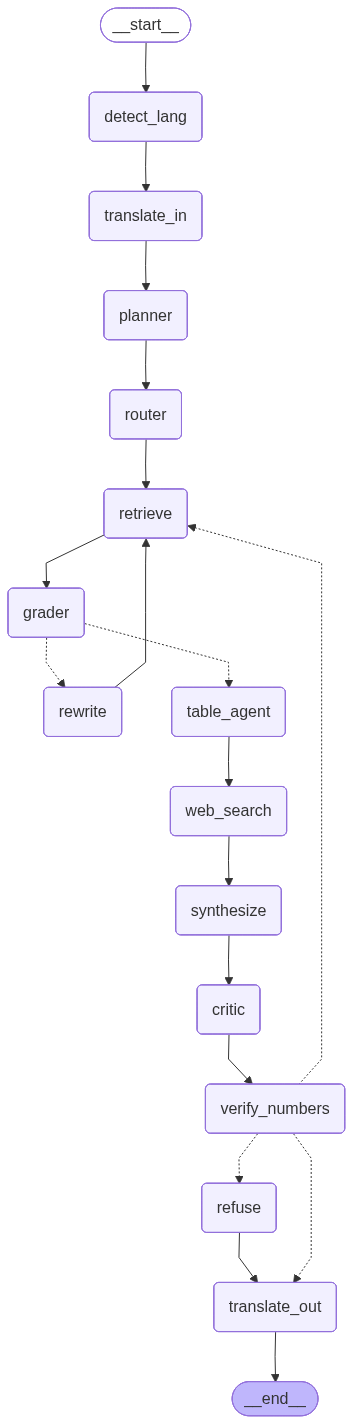

In [48]:
from IPython.display import Image, display
try:
    display(Image(v4_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"({type(e).__name__}: PNG unavailable - showing Mermaid source)\n")
    print(v4_app.get_graph().draw_mermaid())

### Run a query — bilingual demo

A Hindi question — *"रिलायंस का राजस्व FY 2023 में क्या था?"* — exercises the full path: detect Hindi → translate to English for retrieval → answer → translate back to Hindi at the exit.

In [ ]:
state = run_v4("रिलायंस का राजस्व FY 2023 में क्या था?")
print("Original     :", state.get("query_original"))
print("Language     :", state.get("language"))
print("Translated Q :", state.get("question"))
print("Sub-queries  :", state.get("sub_queries"))
print("Routes       :", state.get("query_routes"))
nv = state.get("numeric_verification") or {}
print("Verify score :", nv.get("score"), "| unverified:", len(nv.get("unverified", [])))
print("Refused      :", state.get("refused", False))
print("\nAnswer (in user lang):\n", state.get("final_answer"))
print("\nCitations    :", state.get("citations"))

### BhashaBench-Finance evaluation

A second eval set that's independent of the one we developed against. BhashaBench-Finance has English + Hindi MCQ-style questions; we treat the `Question` as the input and `Answer` as ground truth and let RAGAS score it like FinanceBench.

In [ ]:
from datasets import load_from_disk
bb = load_from_disk("data/India/eval/bhashabench_finance")
print(bb)
bb_train = bb[list(bb.keys())[0]] if hasattr(bb, "keys") else bb
print("columns:", bb_train.column_names if hasattr(bb_train, "column_names") else None)
print("sample :", dict(next(iter(bb_train))))

In [ ]:
# Map BhashaBench columns to question/answer for our run_dataset signature.
import pandas as pd
bb_df = bb_train.to_pandas()
question_col = next((c for c in ("Question","question","query","QUERY") if c in bb_df.columns), None)
answer_col   = next((c for c in ("Answer","answer","ANSWER","correct_answer") if c in bb_df.columns), None)
print("question_col:", question_col, "| answer_col:", answer_col)

# Take a 200-question sample for a reasonable eval window.
bb_sample = bb_df.head(200).rename(columns={question_col: "question", answer_col: "answer"})
bb_outputs = run_corrective_dataset(bb_sample,
                                     output_path="results/v4_bhashabench_outputs.json",
                                     question_col="question",
                                     ground_truth_col="answer")  # see §3.22 if you re-run from scratch

In [ ]:
bb_scores = evaluate_outputs(bb_outputs, sample=50)
metric_cols = [c for c in bb_scores.columns if c in (
    "faithfulness","answer_relevancy","response_relevancy",
    "context_precision","llm_context_precision_with_reference",
    "context_recall","llm_context_recall")]
append_comparison_row("Agentic RAG v4 (BhashaBench)",
                      bb_scores[metric_cols].mean().to_dict())

### Comparison chart

Plot every row in `results/comparison.csv` side-by-side. Saves the figure to `results/comparison.png` for the README.

                 configuration  faithfulness  answer_relevancy  \
0  Agentic RAG v2 (corrective)        0.2857               0.0   

   llm_context_precision_with_reference  context_recall  
0                                   0.0             0.0  


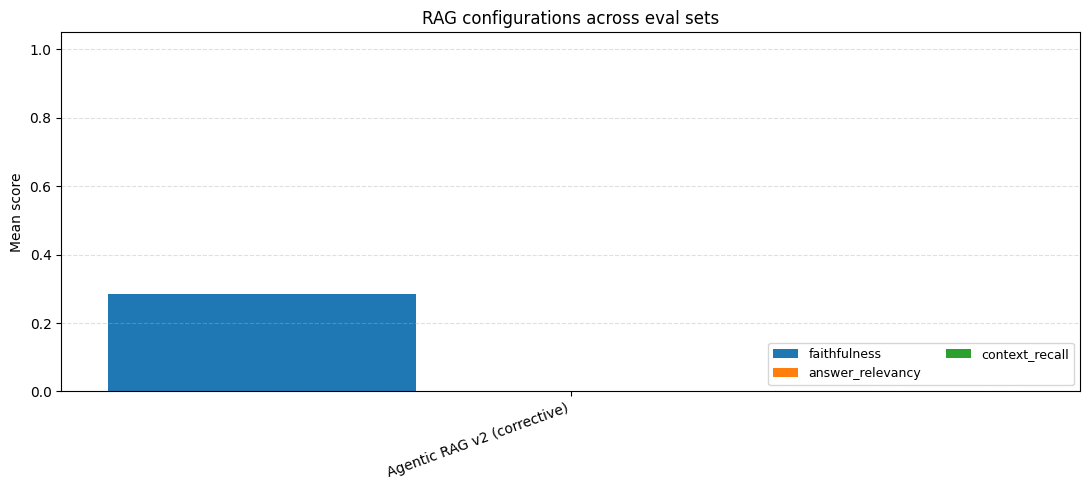

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

cmp = pd.read_csv("results/comparison.csv")
print(cmp)

metric_cols = [c for c in ("faithfulness","answer_relevancy","context_precision","context_recall")
               if c in cmp.columns]

x = list(range(len(cmp)))
width = 0.8 / len(metric_cols)
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metric_cols):
    offsets = [xi + (i - (len(metric_cols)-1)/2) * width for xi in x]
    ax.bar(offsets, cmp[m], width=width, label=m)
ax.set_xticks(x)
ax.set_xticklabels(cmp["configuration"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean score")
ax.set_title("RAG configurations across eval sets")
ax.legend(loc="lower right", ncol=2, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
fig.savefig("results/comparison.png", dpi=140)
plt.show()